In [37]:
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np



In [38]:
PROJECT_ROOT = Path.cwd().parent
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"


con = duckdb.connect()

## Temporal Modeling Strategy

The model will be evaluated using chronological rather than random data splits.

Planned initial structure:

- Training: January–September 2025
- Validation: October–November 2025
- Test: December 2025

This prevents future observations from leaking into model training and better represents real operational deployment.

In [132]:
# Load the processed 2025 BTS flight data

all_flights_path = INTERIM_DIR / "flights_2025_*.parquet"

con.execute(
    f"""
    CREATE OR REPLACE VIEW flights_2025 AS
    SELECT *
    FROM read_parquet('{all_flights_path}')
    """
)

flight_data_summary = con.sql("""
SELECT
    COUNT(*) AS total_rows,
    MIN(FlightDate) AS first_date,
    MAX(FlightDate) AS last_date,
    COUNT(DISTINCT FlightDate) AS days,
    COUNT(DISTINCT Month) AS months
FROM flights_2025
""").df()

flight_data_summary

,total_rows,first_date,last_date,days,months
0,7001619,2025-01-01,2025-12-31,365,12


In [23]:
ingestion_summary = pd.DataFrame(ingestion_results)

ingestion_summary

,year,month,rows,first_date,last_date,days,csv_size_mb,parquet_size_mb,storage_reduction_pct
0,2025,4,583950,2025-04-01,2025-04-30,30,251.85,13.96,94.5
1,2025,5,605648,2025-05-01,2025-05-31,31,261.62,14.33,94.5
2,2025,6,611575,2025-06-01,2025-06-30,30,264.55,14.64,94.5
3,2025,7,631428,2025-07-01,2025-07-31,31,272.92,15.21,94.4
4,2025,8,602378,2025-08-01,2025-08-31,31,260.06,14.49,94.4
5,2025,9,562439,2025-09-01,2025-09-30,30,242.30,13.14,94.6
6,2025,10,605844,2025-10-01,2025-10-31,31,261.98,14.42,94.5
7,2025,11,570550,2025-11-01,2025-11-30,30,246.12,13.84,94.4
8,2025,12,582304,2025-12-01,2025-12-31,31,252.27,14.90,94.1


In [42]:
all_flights_path = INTERIM_DIR / "flights_2025_*.parquet"

con.execute(
    f"""
    CREATE OR REPLACE VIEW flights_2025 AS
    SELECT *
    FROM read_parquet('{all_flights_path}')
    """
)

In [25]:
year_validation = con.sql("""
SELECT
    COUNT(*) AS total_rows,
    MIN(FlightDate) AS first_date,
    MAX(FlightDate) AS last_date,
    COUNT(DISTINCT FlightDate) AS days,
    COUNT(DISTINCT Month) AS months
FROM flights_2025
""").df()

year_validation

,total_rows,first_date,last_date,days,months
0,7001619,2025-01-01,2025-12-31,365,12


In [26]:
monthly_counts = con.sql("""
SELECT
    Month,
    COUNT(*) AS flights
FROM flights_2025
GROUP BY Month
ORDER BY Month
""").df()

monthly_counts

,Month,flights
0,1,539747
1,2,504884
2,3,600872
3,4,583950
4,5,605648
5,6,611575
6,7,631428
7,8,602378
8,9,562439
9,10,605844


## Modeling Population and Target

The modeling population includes completed, non-diverted flights with a known arrival-delay outcome.

The binary target, `significant_arrival_delay`, equals 1 when arrival delay is at least 15 minutes and 0 otherwise.

Only features available before scheduled departure are used for prediction.

In [43]:
modeling_2025 = con.sql("""
SELECT
    Year,
    Quarter,
    Month,
    DayofMonth,
    DayOfWeek,
    FlightDate,

    Reporting_Airline,
    Origin,
    Dest,

    CRSDepTime,
    CRSArrTime,
    CRSElapsedTime,

    Distance,
    DistanceGroup,

    Origin || '_' || Dest AS route,

    CAST(
        FLOOR(CAST(CRSDepTime AS INTEGER) / 100)
        AS INTEGER
    ) AS scheduled_dep_hour,

    CAST(
        FLOOR(CAST(CRSArrTime AS INTEGER) / 100)
        AS INTEGER
    ) AS scheduled_arr_hour,

    CASE
        WHEN DayOfWeek IN (6, 7) THEN 1
        ELSE 0
    END AS is_weekend,

    CASE
        WHEN CAST(CRSDepTime AS INTEGER) < 600 THEN 'overnight'
        WHEN CAST(CRSDepTime AS INTEGER) < 1200 THEN 'morning'
        WHEN CAST(CRSDepTime AS INTEGER) < 1800 THEN 'afternoon'
        ELSE 'evening'
    END AS departure_period,

    ArrDelay,

    CASE
        WHEN ArrDelay >= 15 THEN 1
        ELSE 0
    END AS significant_arrival_delay

FROM flights_2025

WHERE Cancelled = 0
  AND Diverted = 0
  AND ArrDelay IS NOT NULL
""")

In [28]:
modeling_2025.aggregate("""
    COUNT(*) AS modeling_rows
""").df()

,modeling_rows
0,6879484


In [29]:
year_target = con.sql("""
SELECT
    significant_arrival_delay,
    COUNT(*) AS flights,
    ROUND(
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
        2
    ) AS percentage
FROM modeling_2025
GROUP BY significant_arrival_delay
ORDER BY significant_arrival_delay
""").df()

year_target

,significant_arrival_delay,flights,percentage
0,0,5344846,77.69
1,1,1534638,22.31


In [30]:
monthly_target = con.sql("""
SELECT
    Month,
    COUNT(*) AS flights,
    SUM(significant_arrival_delay) AS delayed_flights,
    ROUND(
        AVG(significant_arrival_delay) * 100,
        2
    ) AS delay_rate_pct
FROM modeling_2025
GROUP BY Month
ORDER BY Month
""").df()

monthly_target

,Month,flights,delayed_flights,delay_rate_pct
0,1,522269,98130.0,18.79
1,2,496476,103102.0,20.77
2,3,592301,116034.0,19.59
3,4,577730,113604.0,19.66
4,5,597574,141038.0,23.60
5,6,599472,169405.0,28.26
6,7,612811,177012.0,28.89
7,8,593733,133920.0,22.56
8,9,558328,92859.0,16.63
9,10,601570,122251.0,20.32


In [31]:
train_2025 = con.sql("""
SELECT *
FROM modeling_2025
WHERE Month BETWEEN 1 AND 9
""")

validation_2025 = con.sql("""
SELECT *
FROM modeling_2025
WHERE Month BETWEEN 10 AND 11
""")

test_2025 = con.sql("""
SELECT *
FROM modeling_2025
WHERE Month = 12
""")

In [32]:
split_summary = con.sql("""
SELECT
    'train' AS split,
    COUNT(*) AS flights,
    MIN(FlightDate) AS first_date,
    MAX(FlightDate) AS last_date,
    ROUND(AVG(significant_arrival_delay) * 100, 2) AS delay_rate_pct
FROM train_2025

UNION ALL

SELECT
    'validation',
    COUNT(*),
    MIN(FlightDate),
    MAX(FlightDate),
    ROUND(AVG(significant_arrival_delay) * 100, 2)
FROM validation_2025

UNION ALL

SELECT
    'test',
    COUNT(*),
    MIN(FlightDate),
    MAX(FlightDate),
    ROUND(AVG(significant_arrival_delay) * 100, 2)
FROM test_2025
""").df()

split_summary

,split,flights,first_date,last_date,delay_rate_pct
0,train,5150694,2025-01-01,2025-09-30,22.23
1,validation,1156866,2025-10-01,2025-11-30,20.44
2,test,571924,2025-12-01,2025-12-31,26.77


## Leakage-Safe Cumulative Historical Features

Historical delay features are calculated using only flights from dates prior to each prediction date.

For each carrier, origin airport, destination airport, route, and the overall flight system, daily flight outcomes are aggregated first. Cumulative window functions then summarize all prior observations while explicitly excluding the current date.

This design provides historical operational context without allowing same-day or future outcomes to leak into the prediction features.

In [34]:
carrier_daily = con.sql("""
SELECT
    FlightDate,
    Reporting_Airline,
    COUNT(*) AS daily_flights,
    SUM(significant_arrival_delay) AS daily_delayed_flights
FROM modeling_2025
GROUP BY
    FlightDate,
    Reporting_Airline
""")
carrier_daily


┌────────────┬───────────────────┬───────────────┬───────────────────────┐
│ FlightDate │ Reporting_Airline │ daily_flights │ daily_delayed_flights │
│    date    │      varchar      │     int64     │        int128         │
├────────────┼───────────────────┼───────────────┼───────────────────────┤
│ 2025-01-16 │ AA                │          2596 │                   371 │
│ 2025-01-26 │ AA                │          2547 │                   400 │
│ 2025-01-07 │ AS                │           484 │                   102 │
│ 2025-01-11 │ AS                │           481 │                    87 │
│ 2025-01-19 │ AS                │           611 │                   115 │
│ 2025-01-21 │ AS                │           488 │                    63 │
│ 2025-04-06 │ MQ                │           831 │                   213 │
│ 2025-04-11 │ MQ                │           840 │                   105 │
│ 2025-04-14 │ MQ                │           840 │                    82 │
│ 2025-04-06 │ OH        

In [45]:
carrier_history = con.sql("""
SELECT
    FlightDate,
    Reporting_Airline,

    SUM(daily_flights) OVER (
        PARTITION BY Reporting_Airline
        ORDER BY FlightDate
        ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
    ) AS prior_carrier_flights,

    SUM(daily_delayed_flights) OVER (
        PARTITION BY Reporting_Airline
        ORDER BY FlightDate
        ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
    ) AS prior_carrier_delays

FROM carrier_daily
""")

CatalogException: Catalog Error: Table with name carrier_daily does not exist!
Did you mean "pragma_database_list"?

In [36]:
carrier_history_rates = con.sql("""
SELECT
    FlightDate,
    Reporting_Airline,
    prior_carrier_flights,
    prior_carrier_delays,

    CASE
        WHEN prior_carrier_flights > 0
        THEN prior_carrier_delays * 1.0 / prior_carrier_flights
        ELSE NULL
    END AS carrier_historical_delay_rate

FROM carrier_history
""")

In [38]:
con.sql("""
SELECT *
FROM carrier_history_rates
WHERE Reporting_Airline = 'AA'
ORDER BY FlightDate
LIMIT 10
""").df()

,FlightDate,Reporting_Airline,prior_carrier_flights,prior_carrier_delays,carrier_historical_delay_rate
0,2025-01-01,AA,NaN,NaN,NaN
1,2025-01-02,AA,2403.0,299.0,0.124428
2,2025-01-03,AA,5057.0,718.0,0.141981
3,2025-01-04,AA,7631.0,1264.0,0.165640
4,2025-01-05,AA,10001.0,1831.0,0.183082
5,2025-01-06,AA,12427.0,2812.0,0.226281
6,2025-01-07,AA,14778.0,3960.0,0.267966
7,2025-01-08,AA,16969.0,4319.0,0.254523
8,2025-01-09,AA,19195.0,4681.0,0.243866
9,2025-01-10,AA,21028.0,5106.0,0.242819


In [31]:
origin_daily = con.sql("""
SELECT
    FlightDate,
    Origin,
    COUNT(*) AS daily_flights,
    SUM(significant_arrival_delay) AS daily_delayed_flights
FROM modeling_2025
GROUP BY
    FlightDate,
    Origin
""")

In [36]:
origin_history = con.sql("""
SELECT
    FlightDate,
    Origin,

    SUM(daily_flights) OVER (
        PARTITION BY Origin
        ORDER BY FlightDate
        ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
    ) AS prior_origin_flights,

    SUM(daily_delayed_flights) OVER (
        PARTITION BY Origin
        ORDER BY FlightDate
        ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
    ) AS prior_origin_delays

FROM origin_daily
""")

In [37]:
origin_history_rates = con.sql("""
SELECT
    FlightDate,
    Origin,
    prior_origin_flights,
    prior_origin_delays,

    CASE
        WHEN prior_origin_flights > 0
        THEN prior_origin_delays * 1.0 / prior_origin_flights
        ELSE NULL
    END AS origin_historical_delay_rate

FROM origin_history
""")

In [42]:
con.sql("""
SELECT *
FROM origin_history_rates
WHERE Origin = 'ATL'
ORDER BY FlightDate
LIMIT 10
""").df()

,FlightDate,Origin,prior_origin_flights,prior_origin_delays,origin_historical_delay_rate
0,2025-01-01,ATL,NaN,NaN,NaN
1,2025-01-02,ATL,668.0,93.0,0.139222
2,2025-01-03,ATL,1461.0,249.0,0.170431
3,2025-01-04,ATL,2263.0,402.0,0.177640
4,2025-01-05,ATL,3023.0,647.0,0.214026
5,2025-01-06,ATL,3780.0,904.0,0.239153
6,2025-01-07,ATL,4511.0,1151.0,0.255154
7,2025-01-08,ATL,5213.0,1301.0,0.249568
8,2025-01-09,ATL,5929.0,1419.0,0.239332
9,2025-01-10,ATL,6662.0,1599.0,0.240018


In [32]:
destination_daily = con.sql("""
SELECT
    FlightDate,
    Dest,
    COUNT(*) AS daily_flights,
    SUM(significant_arrival_delay) AS daily_delayed_flights
FROM modeling_2025
GROUP BY
    FlightDate,
    Dest
""")

In [38]:
destination_history = con.sql("""
SELECT
    FlightDate,
    Dest,

    SUM(daily_flights) OVER (
        PARTITION BY Dest
        ORDER BY FlightDate
        ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
    ) AS prior_destination_flights,

    SUM(daily_delayed_flights) OVER (
        PARTITION BY Dest
        ORDER BY FlightDate
        ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
    ) AS prior_destination_delays

FROM destination_daily
""")

In [39]:
destination_history_rates = con.sql("""
SELECT
    FlightDate,
    Dest,
    prior_destination_flights,
    prior_destination_delays,

    CASE
        WHEN prior_destination_flights > 0
        THEN prior_destination_delays * 1.0 / prior_destination_flights
        ELSE NULL
    END AS destination_historical_delay_rate

FROM destination_history
""")

In [46]:
con.sql("""
SELECT *
FROM destination_history_rates
WHERE Dest = 'ATL'
ORDER BY FlightDate
LIMIT 10
""").df()

,FlightDate,Dest,prior_destination_flights,prior_destination_delays,destination_historical_delay_rate
0,2025-01-01,ATL,NaN,NaN,NaN
1,2025-01-02,ATL,663.0,76.0,0.114630
2,2025-01-03,ATL,1465.0,195.0,0.133106
3,2025-01-04,ATL,2265.0,335.0,0.147903
4,2025-01-05,ATL,3031.0,526.0,0.173540
5,2025-01-06,ATL,3806.0,772.0,0.202838
6,2025-01-07,ATL,4515.0,1003.0,0.222148
7,2025-01-08,ATL,5213.0,1121.0,0.215039
8,2025-01-09,ATL,5926.0,1221.0,0.206041
9,2025-01-10,ATL,6635.0,1327.0,0.200000


In [33]:
route_daily = con.sql("""
SELECT
    FlightDate,
    route,
    COUNT(*) AS daily_flights,
    SUM(significant_arrival_delay) AS daily_delayed_flights
FROM modeling_2025
GROUP BY
    FlightDate,
    route
""")

In [40]:
route_history = con.sql("""
SELECT
    FlightDate,
    route,

    SUM(daily_flights) OVER (
        PARTITION BY route
        ORDER BY FlightDate
        ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
    ) AS prior_route_flights,

    SUM(daily_delayed_flights) OVER (
        PARTITION BY route
        ORDER BY FlightDate
        ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
    ) AS prior_route_delays

FROM route_daily
""")

In [41]:
route_history_rates = con.sql("""
SELECT
    FlightDate,
    route,
    prior_route_flights,
    prior_route_delays,

    CASE
        WHEN prior_route_flights > 0
        THEN prior_route_delays * 1.0 / prior_route_flights
        ELSE NULL
    END AS route_historical_delay_rate

FROM route_history
""")

In [50]:
con.sql("""
SELECT *
FROM route_history_rates
WHERE route = 'ATL_MCO'
ORDER BY FlightDate
LIMIT 10
""").df()

,FlightDate,route,prior_route_flights,prior_route_delays,route_historical_delay_rate
0,2025-01-01,ATL_MCO,NaN,NaN,NaN
1,2025-01-02,ATL_MCO,19.0,1.0,0.052632
2,2025-01-03,ATL_MCO,42.0,4.0,0.095238
3,2025-01-04,ATL_MCO,66.0,8.0,0.121212
4,2025-01-05,ATL_MCO,89.0,18.0,0.202247
5,2025-01-06,ATL_MCO,114.0,25.0,0.219298
6,2025-01-07,ATL_MCO,135.0,31.0,0.229630
7,2025-01-08,ATL_MCO,155.0,37.0,0.238710
8,2025-01-09,ATL_MCO,175.0,44.0,0.251429
9,2025-01-10,ATL_MCO,197.0,48.0,0.243655


In [63]:
modeling_with_history = con.sql("""
SELECT
    m.*,

    c.prior_carrier_flights,
    c.carrier_historical_delay_rate,

    o.prior_origin_flights,
    o.origin_historical_delay_rate,

    d.prior_destination_flights,
    d.destination_historical_delay_rate,

    r.prior_route_flights,
    r.route_historical_delay_rate

FROM modeling_2025 m

LEFT JOIN carrier_history_rates c
    ON m.FlightDate = c.FlightDate
   AND m.Reporting_Airline = c.Reporting_Airline

LEFT JOIN origin_history_rates o
    ON m.FlightDate = o.FlightDate
   AND m.Origin = o.Origin

LEFT JOIN destination_history_rates d
    ON m.FlightDate = d.FlightDate
   AND m.Dest = d.Dest

LEFT JOIN route_history_rates r
    ON m.FlightDate = r.FlightDate
   AND m.route = r.route
""")

In [52]:
con.sql("""
SELECT
    (SELECT COUNT(*) FROM modeling_2025) AS original_rows,
    (SELECT COUNT(*) FROM modeling_with_history) AS joined_rows
""").df()

,original_rows,joined_rows
0,6879484,6879484


In [53]:
history_missingness = con.sql("""
SELECT
    COUNT(*) AS total_rows,

    SUM(CASE WHEN carrier_historical_delay_rate IS NULL THEN 1 ELSE 0 END)
        AS missing_carrier_history,

    SUM(CASE WHEN origin_historical_delay_rate IS NULL THEN 1 ELSE 0 END)
        AS missing_origin_history,

    SUM(CASE WHEN destination_historical_delay_rate IS NULL THEN 1 ELSE 0 END)
        AS missing_destination_history,

    SUM(CASE WHEN route_historical_delay_rate IS NULL THEN 1 ELSE 0 END)
        AS missing_route_history

FROM modeling_with_history
""").df()

history_missingness

,total_rows,missing_carrier_history,missing_origin_history,missing_destination_history,missing_route_history
0,6879484,16771.0,16831.0,16833.0,19155.0


In [54]:
con.sql("""
SELECT
    MIN(prior_route_flights) AS min_history,
    PERCENTILE_CONT(0.10) WITHIN GROUP (ORDER BY prior_route_flights) AS p10,
    PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY prior_route_flights) AS p25,
    PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY prior_route_flights) AS median,
    PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY prior_route_flights) AS p75,
    PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY prior_route_flights) AS p90,
    MAX(prior_route_flights) AS max_history
FROM modeling_with_history
WHERE prior_route_flights IS NOT NULL
""").df()

,min_history,p10,p25,median,p75,p90,max_history
0,1.0,116.0,333.0,862.0,1860.0,3317.0,11187.0


In [52]:
system_daily = con.sql("""
SELECT
    FlightDate,
    COUNT(*) AS daily_flights,
    SUM(significant_arrival_delay) AS daily_delayed_flights
FROM modeling_2025
GROUP BY FlightDate
""")

In [53]:
system_history = con.sql("""
SELECT
    FlightDate,

    SUM(daily_flights) OVER (
        ORDER BY FlightDate
        ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
    ) AS prior_system_flights,

    SUM(daily_delayed_flights) OVER (
        ORDER BY FlightDate
        ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
    ) AS prior_system_delays

FROM system_daily
""")

In [54]:
system_history_rates = con.sql("""
SELECT
    FlightDate,
    prior_system_flights,
    prior_system_delays,

    CASE
        WHEN prior_system_flights > 0
        THEN prior_system_delays * 1.0 / prior_system_flights
        ELSE NULL
    END AS system_historical_delay_rate

FROM system_history
""")

In [58]:
con.sql("""
SELECT *
FROM system_history_rates
ORDER BY FlightDate
LIMIT 10
""").df()

,FlightDate,prior_system_flights,prior_system_delays,system_historical_delay_rate
0,2025-01-01,NaN,NaN,NaN
1,2025-01-02,16771.0,2566.0,0.153002
2,2025-01-03,36202.0,5851.0,0.161621
3,2025-01-04,55430.0,11016.0,0.198737
4,2025-01-05,73687.0,16474.0,0.223567
5,2025-01-06,91838.0,22488.0,0.244866
6,2025-01-07,108654.0,29240.0,0.269111
7,2025-01-08,124099.0,33117.0,0.266860
8,2025-01-09,140170.0,35490.0,0.253193
9,2025-01-10,156107.0,39323.0,0.251898


In [64]:
modeling_with_all_history = con.sql("""
SELECT
    m.*,
    s.prior_system_flights,
    s.system_historical_delay_rate

FROM modeling_with_history m

LEFT JOIN system_history_rates s
    ON m.FlightDate = s.FlightDate
""")

In [64]:
con.sql("""
SELECT
    (SELECT COUNT(*) FROM modeling_with_history) AS before_join,
    (SELECT COUNT(*) FROM modeling_with_all_history) AS after_join
""").df()

,before_join,after_join
0,6879484,6879484


### Historical Fallback Strategy

Early dates and low-volume entities may not yet have sufficient historical observations.

To preserve those flights while avoiding imputation from future data, missing entity-level historical rates fall back to broader leakage-safe historical information. For example, a missing carrier rate falls back to the prior system-wide delay rate, while a missing route rate can fall back through origin, destination, carrier, and system history.

Binary missing-history indicators are retained so the model can distinguish observed entity history from fallback values.

In [65]:
modeling_final_features = con.sql("""
SELECT
    *,

    COALESCE(
        carrier_historical_delay_rate,
        system_historical_delay_rate
    ) AS carrier_delay_rate_final,

    COALESCE(
        origin_historical_delay_rate,
        system_historical_delay_rate
    ) AS origin_delay_rate_final,

    COALESCE(
        destination_historical_delay_rate,
        system_historical_delay_rate
    ) AS destination_delay_rate_final,

    COALESCE(
        route_historical_delay_rate,
        origin_historical_delay_rate,
        destination_historical_delay_rate,
        carrier_historical_delay_rate,
        system_historical_delay_rate
    ) AS route_delay_rate_final,

    CASE WHEN carrier_historical_delay_rate IS NULL THEN 1 ELSE 0 END
        AS carrier_history_missing,

    CASE WHEN origin_historical_delay_rate IS NULL THEN 1 ELSE 0 END
        AS origin_history_missing,

    CASE WHEN destination_historical_delay_rate IS NULL THEN 1 ELSE 0 END
        AS destination_history_missing,

    CASE WHEN route_historical_delay_rate IS NULL THEN 1 ELSE 0 END
        AS route_history_missing

FROM modeling_with_all_history
""")

In [66]:
final_history_missingness = con.sql("""
SELECT
    COUNT(*) AS total_rows,

    SUM(CASE WHEN carrier_delay_rate_final IS NULL THEN 1 ELSE 0 END)
        AS missing_carrier_final,

    SUM(CASE WHEN origin_delay_rate_final IS NULL THEN 1 ELSE 0 END)
        AS missing_origin_final,

    SUM(CASE WHEN destination_delay_rate_final IS NULL THEN 1 ELSE 0 END)
        AS missing_destination_final,

    SUM(CASE WHEN route_delay_rate_final IS NULL THEN 1 ELSE 0 END)
        AS missing_route_final

FROM modeling_final_features
""").df()

final_history_missingness

,total_rows,missing_carrier_final,missing_origin_final,missing_destination_final,missing_route_final
0,6879484,16771.0,16771.0,16771.0,16771.0


In [71]:
modeling_ready = con.sql("""
SELECT *
FROM modeling_final_features
WHERE system_historical_delay_rate IS NOT NULL
""")

In [72]:
con.sql("""
SELECT
    COUNT(*) AS modeling_rows,
    MIN(FlightDate) AS first_date,
    MAX(FlightDate) AS last_date,
    COUNT(DISTINCT FlightDate) AS days
FROM modeling_ready
""").df()

,modeling_rows,first_date,last_date,days
0,6862713,2025-01-02,2025-12-31,364


In [76]:
train_final = con.sql("""
SELECT *
FROM modeling_ready
WHERE Month BETWEEN 1 AND 9
""")

validation_final = con.sql("""
SELECT *
FROM modeling_ready
WHERE Month BETWEEN 10 AND 11
""")

test_final = con.sql("""
SELECT *
FROM modeling_ready
WHERE Month = 12
""")

In [77]:
final_split_summary = con.sql("""
SELECT
    'train' AS split,
    COUNT(*) AS rows,
    MIN(FlightDate) AS first_date,
    MAX(FlightDate) AS last_date,
    ROUND(AVG(significant_arrival_delay) * 100, 2) AS delay_rate_pct
FROM train_final

UNION ALL

SELECT
    'validation',
    COUNT(*),
    MIN(FlightDate),
    MAX(FlightDate),
    ROUND(AVG(significant_arrival_delay) * 100, 2)
FROM validation_final

UNION ALL

SELECT
    'test',
    COUNT(*),
    MIN(FlightDate),
    MAX(FlightDate),
    ROUND(AVG(significant_arrival_delay) * 100, 2)
FROM test_final
""").df()

final_split_summary

,split,rows,first_date,last_date,delay_rate_pct
0,train,5133923,2025-01-02,2025-09-30,22.25
1,validation,1156866,2025-10-01,2025-11-30,20.44
2,test,571924,2025-12-01,2025-12-31,26.77


In [4]:
categorical_features = [
    "Reporting_Airline",
    "Origin",
    "Dest"
]

numeric_features = [
    "Month",
    "DayOfWeek",
    "scheduled_dep_hour",
    "scheduled_arr_hour",
    "is_weekend",
    "CRSElapsedTime",
    "Distance",

    "carrier_delay_rate_final",
    "origin_delay_rate_final",
    "destination_delay_rate_final",
    "route_delay_rate_final",

    "prior_carrier_flights",
    "prior_origin_flights",
    "prior_destination_flights",
    "prior_route_flights",

    "carrier_history_missing",
    "origin_history_missing",
    "destination_history_missing",
    "route_history_missing"
]

baseline_v1_features = (
    categorical_features
    + numeric_features
)

len(baseline_v1_features)

22

In [79]:
null_check = con.sql("""
SELECT
    SUM(CASE WHEN CRSElapsedTime IS NULL THEN 1 ELSE 0 END)
        AS missing_crs_elapsed,

    SUM(CASE WHEN Distance IS NULL THEN 1 ELSE 0 END)
        AS missing_distance,

    SUM(CASE WHEN scheduled_dep_hour IS NULL THEN 1 ELSE 0 END)
        AS missing_dep_hour,

    SUM(CASE WHEN scheduled_arr_hour IS NULL THEN 1 ELSE 0 END)
        AS missing_arr_hour,

    SUM(CASE WHEN prior_carrier_flights IS NULL THEN 1 ELSE 0 END)
        AS missing_prior_carrier,

    SUM(CASE WHEN prior_origin_flights IS NULL THEN 1 ELSE 0 END)
        AS missing_prior_origin,

    SUM(CASE WHEN prior_destination_flights IS NULL THEN 1 ELSE 0 END)
        AS missing_prior_destination,

    SUM(CASE WHEN prior_route_flights IS NULL THEN 1 ELSE 0 END)
        AS missing_prior_route

FROM modeling_ready
""").df()

null_check

,missing_crs_elapsed,missing_distance,missing_dep_hour,missing_arr_hour,missing_prior_carrier,missing_prior_origin,missing_prior_destination,missing_prior_route
0,0.0,0.0,0.0,0.0,0.0,60.0,62.0,2384.0


## Baseline v1 — Logistic Regression

The first predictive baseline combines scheduled-flight characteristics, categorical airline and airport identifiers, cumulative leakage-safe historical delay rates, and historical observation counts.

Historical count fields with no prior observations are set to zero, while separate missing-history indicators preserve the cold-start information.

In [80]:
ml_ready = con.sql("""
SELECT
    *,
    
    COALESCE(prior_carrier_flights, 0) AS prior_carrier_flights_ml,
    COALESCE(prior_origin_flights, 0) AS prior_origin_flights_ml,
    COALESCE(prior_destination_flights, 0) AS prior_destination_flights_ml,
    COALESCE(prior_route_flights, 0) AS prior_route_flights_ml

FROM modeling_ready
""")

In [5]:
numeric_features = [
    "Month",
    "DayOfWeek",
    "scheduled_dep_hour",
    "scheduled_arr_hour",
    "is_weekend",
    "CRSElapsedTime",
    "Distance",

    "carrier_delay_rate_final",
    "origin_delay_rate_final",
    "destination_delay_rate_final",
    "route_delay_rate_final",

    "prior_carrier_flights_ml",
    "prior_origin_flights_ml",
    "prior_destination_flights_ml",
    "prior_route_flights_ml",

    "carrier_history_missing",
    "origin_history_missing",
    "destination_history_missing",
    "route_history_missing"
]

baseline_v1_features = categorical_features + numeric_features

print("Baseline features:", len(baseline_v1_features))

Baseline features: 22


In [82]:
null_counts = con.sql("""
SELECT
    COUNT(*) AS rows_with_any_null
FROM ml_ready
WHERE
    Reporting_Airline IS NULL
    OR Origin IS NULL
    OR Dest IS NULL
    OR Month IS NULL
    OR DayOfWeek IS NULL
    OR scheduled_dep_hour IS NULL
    OR scheduled_arr_hour IS NULL
    OR is_weekend IS NULL
    OR CRSElapsedTime IS NULL
    OR Distance IS NULL
    OR carrier_delay_rate_final IS NULL
    OR origin_delay_rate_final IS NULL
    OR destination_delay_rate_final IS NULL
    OR route_delay_rate_final IS NULL
    OR prior_carrier_flights_ml IS NULL
    OR prior_origin_flights_ml IS NULL
    OR prior_destination_flights_ml IS NULL
    OR prior_route_flights_ml IS NULL
    OR carrier_history_missing IS NULL
    OR origin_history_missing IS NULL
    OR destination_history_missing IS NULL
    OR route_history_missing IS NULL
    OR significant_arrival_delay IS NULL
""").df()

null_counts

,rows_with_any_null
0,0


In [83]:
feature_sql = ", ".join(baseline_v1_features)

train_ml = con.sql(f"""
SELECT
    {feature_sql},
    significant_arrival_delay
FROM ml_ready
WHERE Month BETWEEN 1 AND 9
""")

validation_ml = con.sql(f"""
SELECT
    {feature_sql},
    significant_arrival_delay
FROM ml_ready
WHERE Month BETWEEN 10 AND 11
""")

test_ml = con.sql(f"""
SELECT
    {feature_sql},
    significant_arrival_delay
FROM ml_ready
WHERE Month = 12
""")

In [84]:
con.sql("""
SELECT 'train' AS split, COUNT(*) AS rows FROM train_ml

UNION ALL

SELECT 'validation', COUNT(*) FROM validation_ml

UNION ALL

SELECT 'test', COUNT(*) FROM test_ml
""").df()

,split,rows
0,train,5133923
1,validation,1156866
2,test,571924


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [74]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

In [101]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                tol=1e-3,
                class_weight="balanced",
                solver="saga",
                n_jobs=-1
            )
        )
    ]
)

In [89]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

### Baseline Modeling Strategy

Logistic Regression v1 is trained on a reproducible 1,000,000-row sample from the January–September training period.

A large development sample provides a strong baseline while keeping one-hot encoding and iterative model fitting computationally manageable. Validation is performed on the complete October–November holdout period.

In [93]:
train_sample_ml = con.sql(f"""
SELECT
    {feature_sql},
    significant_arrival_delay
FROM ml_ready
WHERE Month BETWEEN 1 AND 9
USING SAMPLE 1000000 ROWS (reservoir, 42)
""")

In [94]:
con.sql("""
SELECT
    'full_train' AS dataset,
    COUNT(*) AS rows,
    ROUND(AVG(significant_arrival_delay) * 100, 2) AS delay_rate_pct
FROM train_ml

UNION ALL

SELECT
    'sample_train',
    COUNT(*),
    ROUND(AVG(significant_arrival_delay) * 100, 2)
FROM train_sample_ml
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,dataset,rows,delay_rate_pct
0,full_train,5133923,22.25
1,sample_train,748229,22.30


In [96]:
train_sample_ml.aggregate("""
    COUNT(*) AS rows
""").df()

,rows
0,1000000


In [97]:
con.sql("""
SELECT
    'full_train' AS dataset,
    COUNT(*) AS rows,
    ROUND(AVG(significant_arrival_delay) * 100, 2) AS delay_rate_pct
FROM train_ml

UNION ALL

SELECT
    'sample_train',
    COUNT(*),
    ROUND(AVG(significant_arrival_delay) * 100, 2)
FROM train_sample_ml
""").df()

,dataset,rows,delay_rate_pct
0,full_train,5133923,22.25
1,sample_train,1000000,22.26


In [98]:
train_df = train_sample_ml.df()

X_train = train_df[baseline_v1_features]
y_train = train_df["significant_arrival_delay"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1000000, 22)
y_train shape: (1000000,)


In [102]:
baseline_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Reporting_Airline',
                                                   'Origin', 'Dest']),
                                                 ('numeric', StandardScaler(),
                                                  ['Month', 'DayOfWeek',
                                                   'scheduled_dep_hour',
                                                   'scheduled_arr_hour',
                                                   'is_weekend',
                                                   'CRSElapsedTime', 'Distance',
                                                   'carrier_delay_rate_final',
                                                   'origin_delay_rate_final',
                                                   'destina...
                                                   'route_delay_rate_final',
                                                   'prior_carrier_flights_ml',
                                                   'prior_origin_flights_ml',
                                                   'prior_destination_flights_ml',
                                                   'prior_route_flights_ml',
                                                   'carrier_history_missing',
                                                   'origin_history_missing',
                                                   'destination_history_missing',
                                                   'route_history_missing'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    n_jobs=-1, solver='saga', tol=0.001))])

In [103]:
classifier = baseline_model.named_steps["classifier"]

print("Iterations used:", classifier.n_iter_)

Iterations used: [506]


# Loading Validation Data

In [105]:
validation_df = validation_ml.df()

X_validation = validation_df[baseline_v1_features]
y_validation = validation_df["significant_arrival_delay"]

print("X_validation shape:", X_validation.shape)
print("y_validation shape:", y_validation.shape)

X_validation shape: (1156866, 22)
y_validation shape: (1156866,)


In [106]:
y_val_pred = baseline_model.predict(X_validation)

y_val_prob = baseline_model.predict_proba(X_validation)[:, 1]

In [107]:
validation_metrics = {
    "accuracy": accuracy_score(y_validation, y_val_pred),
    "precision": precision_score(y_validation, y_val_pred),
    "recall": recall_score(y_validation, y_val_pred),
    "f1": f1_score(y_validation, y_val_pred),
    "roc_auc": roc_auc_score(y_validation, y_val_prob),
    "pr_auc": average_precision_score(y_validation, y_val_prob)
}

validation_metrics

{'accuracy': 0.5795390304495075,
 'precision': 0.27665208628157295,
 'recall': 0.6548910629766391,
 'f1': 0.3889824728009979,
 'roc_auc': np.float64(0.6445144272652213),
 'pr_auc': np.float64(0.29866581536731945)}

In [108]:
confusion_matrix(y_validation, y_val_pred)

array([[515619, 404826],
       [ 81591, 154830]])

In [109]:
import numpy as np

y_naive = np.zeros(len(y_validation), dtype=int)

naive_metrics = {
    "accuracy": accuracy_score(y_validation, y_naive),
    "precision": precision_score(
        y_validation,
        y_naive,
        zero_division=0
    ),
    "recall": recall_score(y_validation, y_naive),
    "f1": f1_score(y_validation, y_naive)
}

naive_metrics

{'accuracy': 0.7956366597341438, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}

In [111]:
import pandas as pd

threshold_results = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    
    predictions = (y_val_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_validation, predictions, zero_division=0
        ),
        "recall": recall_score(
            y_validation, predictions
        ),
        "f1": f1_score(
            y_validation, predictions
        ),
        "accuracy": accuracy_score(
            y_validation, predictions
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(3)

,threshold,precision,recall,f1,accuracy
0,0.30,0.216,0.964,0.353,0.279
1,0.35,0.228,0.918,0.365,0.348
2,0.40,0.242,0.850,0.377,0.427
3,0.45,0.259,0.761,0.387,0.506
4,0.50,0.277,0.655,0.389,0.580
5,0.55,0.295,0.530,0.379,0.645
6,0.60,0.315,0.393,0.349,0.701
7,0.65,0.334,0.247,0.284,0.745
8,0.70,0.357,0.123,0.183,0.776


In [112]:
baseline_results = pd.DataFrame({
    "model": ["Logistic Regression v1"],
    "training_rows": [1_000_000],
    "threshold": [0.50],
    "accuracy": [accuracy_score(y_validation, y_val_pred)],
    "precision": [precision_score(y_validation, y_val_pred)],
    "recall": [recall_score(y_validation, y_val_pred)],
    "f1": [f1_score(y_validation, y_val_pred)],
    "roc_auc": [roc_auc_score(y_validation, y_val_prob)],
    "pr_auc": [average_precision_score(y_validation, y_val_prob)]
})

baseline_results.round(3)

,model,training_rows,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression v1,1000000,0.5,0.58,0.277,0.655,0.389,0.645,0.299


## Baseline Model Evaluation

The first predictive benchmark uses logistic regression trained on a reproducible 1,000,000-row sample from the January–September 2025 training period. The model uses only information available before scheduled departure, including schedule characteristics, airline and airport identifiers, and leakage-safe historical delay features.

The model was evaluated on the temporally held-out October–November validation period.

### Validation Results

| Metric | Score |
|---|---:|
| Accuracy | 0.580 |
| Precision | 0.277 |
| Recall | 0.655 |
| F1 Score | 0.389 |
| ROC-AUC | 0.645 |
| PR-AUC | 0.299 |

A naive classifier that predicts no significant delay for every flight achieves approximately 79.6% accuracy but has zero recall for delayed flights. This demonstrates why accuracy alone is inappropriate for evaluating this imbalanced classification problem.

Threshold analysis showed the expected precision–recall tradeoff, but no tested threshold materially improved overall discrimination. The baseline therefore establishes that scheduled-flight and historical-performance features contain predictive signal, while also indicating that additional operational features are needed.

### Next Step

The next model iteration will incorporate leakage-safe rolling recent-history features to capture short-term changes in carrier, airport, route, and system disruption conditions. The December 2025 test period remains untouched as the final holdout set.

## Baseline v2 — Rolling Recent-History Features

The first logistic regression baseline demonstrated moderate predictive signal from scheduled-flight characteristics and cumulative historical delay rates. However, cumulative rates can respond slowly to changing operational conditions because older observations continue to influence the feature throughout the year.

To capture short-term disruption patterns, the second feature iteration introduces rolling historical delay rates based only on flights occurring during the previous 7 days.

Rolling features are constructed for:

- the overall flight system,
- reporting carrier,
- origin airport,
- destination airport, and
- origin–destination route.

For a flight on date *t*, the rolling window includes information from *t − 7* through *t − 1*. The current day's outcomes are explicitly excluded to prevent target leakage.

These features are intended to capture temporary operational regimes such as periods of elevated congestion, network disruption, or persistent airport and carrier performance deterioration.

In [66]:
system_daily = con.sql("""
SELECT
    FlightDate,
    COUNT(*) AS daily_system_flights,
    SUM(significant_arrival_delay) AS daily_system_delays
FROM modeling_2025
GROUP BY FlightDate
ORDER BY FlightDate
""")

In [67]:
system_7d_history = con.sql("""
SELECT
    FlightDate,

    SUM(daily_system_flights) OVER (
        ORDER BY FlightDate
        RANGE BETWEEN INTERVAL 7 DAY PRECEDING
                  AND INTERVAL 1 DAY PRECEDING
    ) AS prior_7d_system_flights,

    SUM(daily_system_delays) OVER (
        ORDER BY FlightDate
        RANGE BETWEEN INTERVAL 7 DAY PRECEDING
                  AND INTERVAL 1 DAY PRECEDING
    ) AS prior_7d_system_delays

FROM system_daily
ORDER BY FlightDate
""")

In [63]:
system_7d_rates = con.sql("""
SELECT
    *,
    prior_7d_system_delays * 1.0
        / NULLIF(prior_7d_system_flights, 0)
        AS system_delay_rate_7d
FROM system_7d_history
""")

In [122]:
system_7d_rates.limit(12).df()

,FlightDate,prior_7d_system_flights,prior_7d_system_delays,system_delay_rate_7d
0,2025-01-01,NaN,NaN,NaN
1,2025-01-02,16771.0,2566.0,0.153002
2,2025-01-03,36202.0,5851.0,0.161621
3,2025-01-04,55430.0,11016.0,0.198737
4,2025-01-05,73687.0,16474.0,0.223567
5,2025-01-06,91838.0,22488.0,0.244866
6,2025-01-07,108654.0,29240.0,0.269111
7,2025-01-08,124099.0,33117.0,0.266860
8,2025-01-09,123399.0,32924.0,0.266809
9,2025-01-10,119905.0,33472.0,0.279154


In [66]:
carrier_daily = con.sql("""
SELECT
    FlightDate,
    Reporting_Airline,
    COUNT(*) AS daily_carrier_flights,
    SUM(significant_arrival_delay) AS daily_carrier_delays
FROM modeling_2025
GROUP BY
    FlightDate,
    Reporting_Airline
""")

In [67]:
carrier_7d_history = con.sql("""
SELECT
    FlightDate,
    Reporting_Airline,

    SUM(daily_carrier_flights) OVER (
        PARTITION BY Reporting_Airline
        ORDER BY FlightDate
        RANGE BETWEEN INTERVAL 7 DAY PRECEDING
                  AND INTERVAL 1 DAY PRECEDING
    ) AS prior_7d_carrier_flights,

    SUM(daily_carrier_delays) OVER (
        PARTITION BY Reporting_Airline
        ORDER BY FlightDate
        RANGE BETWEEN INTERVAL 7 DAY PRECEDING
                  AND INTERVAL 1 DAY PRECEDING
    ) AS prior_7d_carrier_delays

FROM carrier_daily
""")

In [68]:
carrier_7d_rates = con.sql("""
SELECT
    *,
    prior_7d_carrier_delays * 1.0
        / NULLIF(prior_7d_carrier_flights, 0)
        AS carrier_delay_rate_7d
FROM carrier_7d_history
""")

In [127]:
con.sql("""
SELECT *
FROM carrier_7d_rates
WHERE Reporting_Airline = 'AA'
ORDER BY FlightDate
LIMIT 12
""").df()

,FlightDate,Reporting_Airline,prior_7d_carrier_flights,prior_7d_carrier_delays,carrier_delay_rate_7d
0,2025-01-01,AA,NaN,NaN,NaN
1,2025-01-02,AA,2403.0,299.0,0.124428
2,2025-01-03,AA,5057.0,718.0,0.141981
3,2025-01-04,AA,7631.0,1264.0,0.165640
4,2025-01-05,AA,10001.0,1831.0,0.183082
5,2025-01-06,AA,12427.0,2812.0,0.226281
6,2025-01-07,AA,14778.0,3960.0,0.267966
7,2025-01-08,AA,16969.0,4319.0,0.254523
8,2025-01-09,AA,16792.0,4382.0,0.260958
9,2025-01-10,AA,15971.0,4388.0,0.274748


In [69]:
origin_daily = con.sql("""
SELECT
    FlightDate,
    Origin,
    COUNT(*) AS daily_origin_flights,
    SUM(significant_arrival_delay) AS daily_origin_delays
FROM modeling_2025
GROUP BY
    FlightDate,
    Origin
""")

origin_7d_history = con.sql("""
SELECT
    FlightDate,
    Origin,

    SUM(daily_origin_flights) OVER (
        PARTITION BY Origin
        ORDER BY FlightDate
        RANGE BETWEEN INTERVAL 7 DAY PRECEDING
                  AND INTERVAL 1 DAY PRECEDING
    ) AS prior_7d_origin_flights,

    SUM(daily_origin_delays) OVER (
        PARTITION BY Origin
        ORDER BY FlightDate
        RANGE BETWEEN INTERVAL 7 DAY PRECEDING
                  AND INTERVAL 1 DAY PRECEDING
    ) AS prior_7d_origin_delays

FROM origin_daily
""")

origin_7d_rates = con.sql("""
SELECT
    *,
    prior_7d_origin_delays * 1.0
        / NULLIF(prior_7d_origin_flights, 0)
        AS origin_delay_rate_7d
FROM origin_7d_history
""")

In [70]:
destination_daily = con.sql("""
SELECT
    FlightDate,
    Dest,
    COUNT(*) AS daily_destination_flights,
    SUM(significant_arrival_delay) AS daily_destination_delays
FROM modeling_2025
GROUP BY
    FlightDate,
    Dest
""")

destination_7d_history = con.sql("""
SELECT
    FlightDate,
    Dest,

    SUM(daily_destination_flights) OVER (
        PARTITION BY Dest
        ORDER BY FlightDate
        RANGE BETWEEN INTERVAL 7 DAY PRECEDING
                  AND INTERVAL 1 DAY PRECEDING
    ) AS prior_7d_destination_flights,

    SUM(daily_destination_delays) OVER (
        PARTITION BY Dest
        ORDER BY FlightDate
        RANGE BETWEEN INTERVAL 7 DAY PRECEDING
                  AND INTERVAL 1 DAY PRECEDING
    ) AS prior_7d_destination_delays

FROM destination_daily
""")

destination_7d_rates = con.sql("""
SELECT
    *,
    prior_7d_destination_delays * 1.0
        / NULLIF(prior_7d_destination_flights, 0)
        AS destination_delay_rate_7d
FROM destination_7d_history
""")

In [71]:
route_daily = con.sql("""
SELECT
    FlightDate,
    route,
    COUNT(*) AS daily_route_flights,
    SUM(significant_arrival_delay) AS daily_route_delays
FROM modeling_2025
GROUP BY
    FlightDate,
    route
""")

route_7d_history = con.sql("""
SELECT
    FlightDate,
    route,

    SUM(daily_route_flights) OVER (
        PARTITION BY route
        ORDER BY FlightDate
        RANGE BETWEEN INTERVAL 7 DAY PRECEDING
                  AND INTERVAL 1 DAY PRECEDING
    ) AS prior_7d_route_flights,

    SUM(daily_route_delays) OVER (
        PARTITION BY route
        ORDER BY FlightDate
        RANGE BETWEEN INTERVAL 7 DAY PRECEDING
                  AND INTERVAL 1 DAY PRECEDING
    ) AS prior_7d_route_delays

FROM route_daily
""")

route_7d_rates = con.sql("""
SELECT
    *,
    prior_7d_route_delays * 1.0
        / NULLIF(prior_7d_route_flights, 0)
        AS route_delay_rate_7d
FROM route_7d_history
""")

In [131]:
con.sql("""
SELECT *
FROM route_7d_rates
WHERE route = 'ATL_MCO'
ORDER BY FlightDate
LIMIT 12
""").df()

,FlightDate,route,prior_7d_route_flights,prior_7d_route_delays,route_delay_rate_7d
0,2025-01-01,ATL_MCO,NaN,NaN,NaN
1,2025-01-02,ATL_MCO,19.0,1.0,0.052632
2,2025-01-03,ATL_MCO,42.0,4.0,0.095238
3,2025-01-04,ATL_MCO,66.0,8.0,0.121212
4,2025-01-05,ATL_MCO,89.0,18.0,0.202247
5,2025-01-06,ATL_MCO,114.0,25.0,0.219298
6,2025-01-07,ATL_MCO,135.0,31.0,0.229630
7,2025-01-08,ATL_MCO,155.0,37.0,0.238710
8,2025-01-09,ATL_MCO,156.0,43.0,0.275641
9,2025-01-10,ATL_MCO,155.0,44.0,0.283871


## Joining Rolling 7-Day Features

The rolling 7-day features are joined back to each individual flight using the flight date and the relevant grouping key.

Each feature uses only information from the previous seven calendar days and excludes the current day, preserving the predeparture prediction constraint.

After joining, row counts are validated to ensure that feature engineering has not duplicated or removed flights.

In [68]:
modeling_with_7d = con.sql("""
SELECT
    m.*,

    s.prior_7d_system_flights,
    s.system_delay_rate_7d,

    c.prior_7d_carrier_flights,
    c.carrier_delay_rate_7d,

    o.prior_7d_origin_flights,
    o.origin_delay_rate_7d,

    d.prior_7d_destination_flights,
    d.destination_delay_rate_7d,

    r.prior_7d_route_flights,
    r.route_delay_rate_7d

FROM modeling_final_features m

LEFT JOIN system_7d_rates s
    ON m.FlightDate = s.FlightDate

LEFT JOIN carrier_7d_rates c
    ON m.FlightDate = c.FlightDate
   AND m.Reporting_Airline = c.Reporting_Airline

LEFT JOIN origin_7d_rates o
    ON m.FlightDate = o.FlightDate
   AND m.Origin = o.Origin

LEFT JOIN destination_7d_rates d
    ON m.FlightDate = d.FlightDate
   AND m.Dest = d.Dest

LEFT JOIN route_7d_rates r
    ON m.FlightDate = r.FlightDate
   AND m.route = r.route
""")

In [133]:
con.sql("""
SELECT
    (SELECT COUNT(*) FROM modeling_final_features) AS before_join,
    (SELECT COUNT(*) FROM modeling_with_7d) AS after_join
""").df()

,before_join,after_join
0,6879484,6879484


In [134]:
con.sql("""
SELECT
    COUNT(*) AS total_rows,

    SUM(CASE WHEN system_delay_rate_7d IS NULL THEN 1 ELSE 0 END)
        AS missing_system_7d,

    SUM(CASE WHEN carrier_delay_rate_7d IS NULL THEN 1 ELSE 0 END)
        AS missing_carrier_7d,

    SUM(CASE WHEN origin_delay_rate_7d IS NULL THEN 1 ELSE 0 END)
        AS missing_origin_7d,

    SUM(CASE WHEN destination_delay_rate_7d IS NULL THEN 1 ELSE 0 END)
        AS missing_destination_7d,

    SUM(CASE WHEN route_delay_rate_7d IS NULL THEN 1 ELSE 0 END)
        AS missing_route_7d

FROM modeling_with_7d
""").df()

,total_rows,missing_system_7d,missing_carrier_7d,missing_origin_7d,missing_destination_7d,missing_route_7d
0,6879484,16771.0,16771.0,16862.0,16862.0,21077.0


In [ ]:
modeling_v2 = con.sql("""
SELECT
    *,

    -- Cumulative-history count fallbacks
    COALESCE(prior_carrier_flights, 0)
        AS prior_carrier_flights_ml,

    COALESCE(prior_origin_flights, 0)
        AS prior_origin_flights_ml,

    COALESCE(prior_destination_flights, 0)
        AS prior_destination_flights_ml,

    COALESCE(prior_route_flights, 0)
        AS prior_route_flights_ml,

    -- 7-day delay-rate fallbacks
    COALESCE(
        carrier_delay_rate_7d,
        system_delay_rate_7d
    ) AS carrier_delay_rate_7d_final,

    COALESCE(
        origin_delay_rate_7d,
        system_delay_rate_7d
    ) AS origin_delay_rate_7d_final,

    COALESCE(
        destination_delay_rate_7d,
        system_delay_rate_7d
    ) AS destination_delay_rate_7d_final,

    COALESCE(
        route_delay_rate_7d,
        origin_delay_rate_7d,
        destination_delay_rate_7d,
        carrier_delay_rate_7d,
        system_delay_rate_7d
    ) AS route_delay_rate_7d_final,

    -- 7-day history-count fallbacks
    COALESCE(prior_7d_carrier_flights, 0)
        AS prior_7d_carrier_flights_ml,

    COALESCE(prior_7d_origin_flights, 0)
        AS prior_7d_origin_flights_ml,

    COALESCE(prior_7d_destination_flights, 0)
        AS prior_7d_destination_flights_ml,

    COALESCE(prior_7d_route_flights, 0)
        AS prior_7d_route_flights_ml,

    -- 7-day missing-history indicators
    CASE WHEN carrier_delay_rate_7d IS NULL THEN 1 ELSE 0 END
        AS carrier_7d_missing,

    CASE WHEN origin_delay_rate_7d IS NULL THEN 1 ELSE 0 END
        AS origin_7d_missing,

    CASE WHEN destination_delay_rate_7d IS NULL THEN 1 ELSE 0 END
        AS destination_7d_missing,

    CASE WHEN route_delay_rate_7d IS NULL THEN 1 ELSE 0 END
        AS route_7d_missing

FROM modeling_with_7d

WHERE system_delay_rate_7d IS NOT NULL
""")

In [141]:
con.sql("""
SELECT
    COUNT(*) AS rows,
    MIN(FlightDate) AS first_date,
    MAX(FlightDate) AS last_date,

    SUM(CASE WHEN carrier_delay_rate_7d_final IS NULL THEN 1 ELSE 0 END)
        AS missing_carrier,

    SUM(CASE WHEN origin_delay_rate_7d_final IS NULL THEN 1 ELSE 0 END)
        AS missing_origin,

    SUM(CASE WHEN destination_delay_rate_7d_final IS NULL THEN 1 ELSE 0 END)
        AS missing_destination,

    SUM(CASE WHEN route_delay_rate_7d_final IS NULL THEN 1 ELSE 0 END)
        AS missing_route

FROM modeling_v2
""").df()

,rows,first_date,last_date,missing_carrier,missing_origin,missing_destination,missing_route
0,6862713,2025-01-02,2025-12-31,0.0,0.0,0.0,0.0


## Baseline v2 Model

Baseline v2 extends the original logistic regression model with leakage-safe 7-day rolling operational-history features.

The original cumulative historical features are retained to represent long-term performance, while the rolling features capture recent operational conditions.

To make the comparison with Baseline v1 meaningful, the modeling framework remains unchanged:

- Logistic regression
- 1,000,000 training observations
- January–September training period
- October–November validation period
- December final holdout period
- Identical preprocessing and evaluation metrics

The objective is to determine whether recent operational history provides incremental predictive value beyond cumulative historical performance.

In [12]:
rolling_7d_features = [
    "carrier_delay_rate_7d_final",
    "origin_delay_rate_7d_final",
    "destination_delay_rate_7d_final",
    "route_delay_rate_7d_final",
    "prior_7d_carrier_flights_ml",
    "prior_7d_origin_flights_ml",
    "prior_7d_destination_flights_ml",
    "prior_7d_route_flights_ml",
    "carrier_7d_missing",
    "origin_7d_missing",
    "destination_7d_missing",
    "route_7d_missing"
]

baseline_v2_features = baseline_v1_features + rolling_7d_features

print("Baseline v1 features:", len(baseline_v1_features))
print("New rolling features:", len(rolling_7d_features))
print("Baseline v2 features:", len(baseline_v2_features))

Baseline v1 features: 22
New rolling features: 12
Baseline v2 features: 34


In [16]:
categorical_features_v2 = categorical_features.copy()

numeric_features_v2 = [
    feature
    for feature in baseline_v2_features
    if feature not in categorical_features_v2
]

print("Categorical:", len(categorical_features_v2))
print("Numeric:", len(numeric_features_v2))
print("Total:", len(categorical_features_v2) + len(numeric_features_v2))

Categorical: 3
Numeric: 31
Total: 34


In [ ]:
feature_sql_v2 = ", ".join(baseline_v2_features)

train_v2 = con.sql(f"""
SELECT
    {feature_sql_v2},
    significant_arrival_delay
FROM modeling_v2
WHERE FlightDate < DATE '2025-10-01'
""")

validation_v2 = con.sql(f"""
SELECT
    {feature_sql_v2},
    significant_arrival_delay
FROM modeling_v2
WHERE FlightDate >= DATE '2025-10-01'
  AND FlightDate < DATE '2025-12-01'
""")

In [147]:
con.sql("""
SELECT
    'train' AS split,
    COUNT(*) AS rows,
    ROUND(AVG(significant_arrival_delay) * 100, 2) AS delay_rate_pct
FROM train_v2

UNION ALL

SELECT
    'validation',
    COUNT(*),
    ROUND(AVG(significant_arrival_delay) * 100, 2)
FROM validation_v2
""").df()

: 

## Baseline v2 Training

Baseline v2 retains the logistic-regression framework used in Baseline v1 but expands the feature set from 22 to 34 predictors by adding leakage-safe 7-day rolling operational-history features.

To keep the comparison fair:

- Training remains restricted to January–September 2025.
- Validation remains October–November 2025.
- December 2025 remains untouched.
- The training sample remains 1,000,000 observations.
- The same categorical preprocessing, numeric scaling, class balancing, solver, and optimization tolerance are used.

Any improvement in validation performance can therefore be attributed primarily to the addition of recent operational-history features rather than to a different modeling algorithm.

In [ ]:
train_sample_v2 = con.sql(f"""
SELECT
    {feature_sql_v2},
    significant_arrival_delay
FROM modeling_v2
WHERE FlightDate < DATE '2025-10-01'
USING SAMPLE 1000000 ROWS (reservoir, 42)
""")

In [27]:
con.sql("""
SELECT
    COUNT(*) AS rows,
    ROUND(
        AVG(significant_arrival_delay) * 100,
        2
    ) AS delay_rate_pct
FROM train_sample_v2
""").df()

,rows,delay_rate_pct
0,1000000,22.32


In [75]:
preprocessor_v2 = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features_v2
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features_v2
        )
    ]
)

In [31]:
baseline_model_v2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_v2),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                tol=1e-3,
                class_weight="balanced",
                solver="saga",
                random_state=42
            )
        )
    ]
)

In [32]:
baseline_model_v2.fit(
    X_train_v2,
    y_train_v2
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Reporting_Airline',
                                                   'Origin', 'Dest']),
                                                 ('numeric', StandardScaler(),
                                                  ['Month', 'DayOfWeek',
                                                   'scheduled_dep_hour',
                                                   'scheduled_arr_hour',
                                                   'is_weekend',
                                                   'CRSElapsedTime', 'Distance',
                                                   'carrier_delay_rate_final',
                                                   'origin_delay_rate_final',
                                                   'destina...
                                                   'destination_delay_rate_7d_final',
                                                   'route_delay_rate_7d_final',
                                                   'prior_7d_carrier_flights_ml',
                                                   'prior_7d_origin_flights_ml',
                                                   'prior_7d_destination_flights_ml',
                                                   'prior_7d_route_flights_ml',
                                                   'carrier_7d_missing',
                                                   'origin_7d_missing',
                                                   'destination_7d_missing', ...])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42, solver='saga',
                                    tol=0.001))])

In [33]:
classifier_v2 = baseline_model_v2.named_steps["classifier"]

print(
    "Iterations used:",
    classifier_v2.n_iter_
)

Iterations used: [602]


### Baseline v2 Validation

Baseline v2 converged successfully after 602 iterations using the same logistic-regression configuration as Baseline v1.

The next step evaluates the model on the unchanged October–November validation period and compares the results directly with Baseline v1 to determine whether the 7-day rolling operational-history features add predictive value.

In [34]:
validation_df_v2 = validation_v2.df()

X_validation_v2 = validation_df_v2[baseline_v2_features]
y_validation_v2 = validation_df_v2["significant_arrival_delay"]

print(X_validation_v2.shape)

(1156866, 34)


In [37]:
y_val_pred_v2 = baseline_model_v2.predict(X_validation_v2)

y_val_prob_v2 = baseline_model_v2.predict_proba(
    X_validation_v2
)[:, 1]

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

In [39]:
validation_metrics_v2 = {
    "accuracy": accuracy_score(y_validation_v2, y_val_pred_v2),
    "precision": precision_score(y_validation_v2, y_val_pred_v2),
    "recall": recall_score(y_validation_v2, y_val_pred_v2),
    "f1": f1_score(y_validation_v2, y_val_pred_v2),
    "roc_auc": roc_auc_score(y_validation_v2, y_val_prob_v2),
    "pr_auc": average_precision_score(y_validation_v2, y_val_prob_v2)
}

validation_metrics_v2

{'accuracy': 0.6479047703018327,
 'precision': 0.30323788383959327,
 'recall': 0.5570359655022185,
 'f1': 0.3926991562760449,
 'roc_auc': np.float64(0.6591580801875917),
 'pr_auc': np.float64(0.31693132885157)}

In [42]:
validation_metrics_v2 = {
    "accuracy": accuracy_score(y_validation_v2, y_val_pred_v2),
    "precision": precision_score(y_validation_v2, y_val_pred_v2),
    "recall": recall_score(y_validation_v2, y_val_pred_v2),
    "f1": f1_score(y_validation_v2, y_val_pred_v2),
    "roc_auc": roc_auc_score(y_validation_v2, y_val_prob_v2),
    "pr_auc": average_precision_score(y_validation_v2, y_val_prob_v2)
}

validation_metrics_v2

{'accuracy': 0.6479047703018327,
 'precision': 0.30323788383959327,
 'recall': 0.5570359655022185,
 'f1': 0.3926991562760449,
 'roc_auc': np.float64(0.6591580801875917),
 'pr_auc': np.float64(0.31693132885157)}

In [41]:
confusion_matrix(
    y_validation_v2,
    y_val_pred_v2
)

array([[617844, 302601],
       [104726, 131695]])

### Baseline v2 Results

Adding leakage-safe 7-day rolling operational-history features improved the model's ability to distinguish higher-risk flights.

| Metric | Baseline v1 | Baseline v2 |
|---|---:|---:|
| Accuracy | 0.580 | 0.648 |
| Precision | 0.277 | 0.303 |
| Recall | 0.655 | 0.557 |
| F1 Score | 0.389 | 0.393 |
| ROC-AUC | 0.645 | 0.659 |
| PR-AUC | 0.299 | 0.317 |

The improvement in ROC-AUC and PR-AUC indicates that recent operational history provides incremental predictive information beyond cumulative historical performance.

At the default 0.50 classification threshold, Baseline v2 became more selective: precision and accuracy increased while recall decreased. Because threshold-dependent metrics can be adjusted later according to operational objectives, ROC-AUC and PR-AUC provide stronger evidence that the underlying ranking performance improved.

The improvement is meaningful but modest, suggesting that additional variations of historical-delay features alone are unlikely to produce a major increase in predictive performance. The next modeling stage should introduce new sources of information rather than continuing to optimize variations of the same historical signals.

# Phase 3 — NOAA Weather Integration

Baseline v2 demonstrated that recent operational history improves flight-delay prediction, but the improvement was modest. The next phase introduces an independent source of predictive information: historical weather observations.

Hourly weather data will be integrated with the BTS flight dataset using NOAA's Global Historical Climatology Network Hourly (GHCNh).

The weather pipeline will follow:

BTS Airport → NOAA Weather Station → Observation Timestamp → Weather Features → Flight Record

The initial weather feature set will focus on operationally relevant conditions available before scheduled departure, including:

- Temperature
- Dew point
- Relative humidity
- Wind speed
- Wind gust
- Visibility
- Precipitation
- Atmospheric pressure
- Sky conditions
- Present-weather indicators where available

Weather features will be constructed under the same leakage-control principle used throughout the project: information recorded after the prediction point will not be used.

December 2025 remains untouched as the final model holdout.

In [43]:
airport_summary = con.sql("""
SELECT
    airport,
    COUNT(*) AS flight_count
FROM (
    SELECT Origin AS airport
    FROM modeling_2025

    UNION ALL

    SELECT Dest AS airport
    FROM modeling_2025
)
GROUP BY airport
ORDER BY flight_count DESC
""").df()

print("Distinct airports:", len(airport_summary))

airport_summary.head(20)

Distinct airports: 352


,airport,flight_count
0,ORD,640515
1,DEN,627765
2,ATL,617859
3,DFW,611527
4,PHX,389639
5,CLT,383339
6,LAX,377447
7,LAS,364068
8,SEA,325942
9,MCO,315505


In [44]:
airport_summary["cumulative_flights"] = airport_summary["flight_count"].cumsum()

airport_summary["cumulative_pct"] = (
    airport_summary["cumulative_flights"]
    / airport_summary["flight_count"].sum()
    * 100
)

airport_summary.head(20)

,airport,flight_count,cumulative_flights,cumulative_pct
0,ORD,640515,640515,4.655255
1,DEN,627765,1268280,9.217843
2,ATL,617859,1886139,13.708434
3,DFW,611527,2497666,18.153004
4,PHX,389639,2887305,20.984895
5,CLT,383339,3270644,23.770998
6,LAX,377447,3648091,26.514278
7,LAS,364068,4012159,29.160319
8,SEA,325942,4338101,31.529261
9,MCO,315505,4653606,33.822348


In [45]:
for threshold in [80, 90, 95, 99]:
    airports_needed = (
        airport_summary["cumulative_pct"] < threshold
    ).sum() + 1

    print(
        f"Airports needed for {threshold}% of traffic: "
        f"{airports_needed}"
    )

Airports needed for 80% of traffic: 54
Airports needed for 90% of traffic: 92
Airports needed for 95% of traffic: 133
Airports needed for 99% of traffic: 232


## Transition to Weather Integration

The BTS-only modeling phase established two predictive benchmarks using temporally valid predeparture information.

Baseline v1 combined scheduled-flight characteristics with cumulative historical operational performance. Baseline v2 added leakage-safe 7-day rolling history and improved validation ROC-AUC from 0.645 to 0.659 and PR-AUC from 0.299 to 0.317.

Further transformations of historical delay performance are unlikely to provide a major increase in predictive power without introducing new information. The next phase therefore incorporates historical weather observations.

The 2025 BTS network contains 352 distinct airports. Airport traffic is concentrated but remains geographically broad:

- 54 airports account for 80% of flight endpoints
- 92 airports account for 90%
- 133 airports account for 95%
- 232 airports account for 99%

Weather integration will first be validated on high-volume airports before the station-matching and ingestion pipeline is generalized across the network.

Weather acquisition, airport-to-station mapping, temporal alignment, data-quality validation, and weather feature engineering are developed separately in `03_weather_integration.ipynb`.

December 2025 remains untouched as the final model holdout.


In [13]:
print("Categorical:", len(categorical_features_v2))
print("Numeric:", len(numeric_features_v2))
print("Total:", len(baseline_v2_features))

baseline_v2_features

Categorical: 3
Numeric: 31
Total: 34


['Reporting_Airline',
 'Origin',
 'Dest',
 'Month',
 'DayOfWeek',
 'scheduled_dep_hour',
 'scheduled_arr_hour',
 'is_weekend',
 'CRSElapsedTime',
 'Distance',
 'carrier_delay_rate_final',
 'origin_delay_rate_final',
 'destination_delay_rate_final',
 'route_delay_rate_final',
 'prior_carrier_flights',
 'prior_origin_flights',
 'prior_destination_flights',
 'prior_route_flights',
 'carrier_history_missing',
 'origin_history_missing',
 'destination_history_missing',
 'route_history_missing',
 'carrier_delay_rate_7d_final',
 'origin_delay_rate_7d_final',
 'destination_delay_rate_7d_final',
 'route_delay_rate_7d_final',
 'prior_7d_carrier_flights_ml',
 'prior_7d_origin_flights_ml',
 'prior_7d_destination_flights_ml',
 'prior_7d_route_flights_ml',
 'carrier_7d_missing',
 'origin_7d_missing',
 'destination_7d_missing',
 'route_7d_missing']

In [18]:
weather_features_v3 = [
    "wx_temperature_c",
    "wx_wind_speed_ms",
    "wx_visibility_km",
    "wx_pressure_hpa",
    "wx_precipitation",
    "wx_ceiling_m",
    "wx_temperature_missing",
    "wx_wind_missing",
    "wx_visibility_missing",
    "wx_pressure_missing",
    "wx_precipitation_missing",
    "wx_ceiling_missing",
]

In [19]:
numeric_features_v3 = (
    numeric_features_v2
    + weather_features_v3
)

categorical_features_v3 = categorical_features_v2

baseline_v3_features = (
    categorical_features_v3
    + numeric_features_v3
)

print("Categorical features:", len(categorical_features_v3))
print("Numeric features:", len(numeric_features_v3))
print("Total features:", len(baseline_v3_features))

Categorical features: 3
Numeric features: 43
Total features: 46


## Baseline v3 — Add Point-in-Time NOAA Weather

Baseline v3 extends the previously validated Baseline v2 feature set with leakage-safe NOAA weather features observed at the origin airport before scheduled departure.

The Baseline v2 feature definition is preserved unchanged. Twelve weather variables are added:

- temperature
- wind speed
- visibility
- sea-level pressure
- precipitation
- ceiling height
- missingness indicators for each weather variable

This creates a 46-feature model and allows the incremental predictive value of weather to be evaluated directly against Baseline v2 using the same temporal validation framework.

### Load Persisted NOAA Weather Features

The completed weather-integration pipeline is consumed through its persisted flight-level Parquet artifact rather than rebuilding NOAA station mapping, downloads, timezone conversion, or point-in-time weather matching.

The artifact will be joined to the existing Baseline v2 modeling relation using the previously validated composite flight key.

In [79]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

WEATHER_ML_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "weather"
    / "flight_weather_features_2025.parquet"
)

print("Exists:", WEATHER_ML_PATH.exists())
print("Size MB:", round(WEATHER_ML_PATH.stat().st_size / 1024**2, 2))

Exists: True
Size MB: 24.09


In [80]:
con.sql(f"""
CREATE OR REPLACE VIEW weather_ml_2025 AS
SELECT *
FROM read_parquet('{WEATHER_ML_PATH}')
""")

In [22]:
con.sql("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT Reporting_Airline) AS airlines,
    COUNT(DISTINCT Origin) AS origins,
    MIN(FlightDate) AS first_date,
    MAX(FlightDate) AS last_date
FROM weather_ml_2025
""").df()

,rows,airlines,origins,first_date,last_date
0,6879484,14,352,2025-01-01,2025-12-31


In [23]:
con.sql("""
SHOW TABLES
""").df()

,name
0,weather_ml_2025


In [24]:
from pathlib import Path
import duckdb

PROJECT_ROOT = Path.cwd().parent
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"

all_flights_path = INTERIM_DIR / "flights_2025_*.parquet"

con.sql(f"""
CREATE OR REPLACE VIEW flights_2025 AS

SELECT *
FROM read_parquet('{all_flights_path}')
""")

In [25]:
con.sql("""
SELECT
    COUNT(*) AS rows,
    MIN(FlightDate) AS first_date,
    MAX(FlightDate) AS last_date
FROM flights_2025
""").df()

,rows,first_date,last_date
0,7001619,2025-01-01,2025-12-31


In [26]:
con.sql("""
CREATE OR REPLACE VIEW modeling_base AS

SELECT
    *,
    
    CASE
        WHEN ArrDelay >= 15 THEN 1
        ELSE 0
    END AS significant_arrival_delay,

    CAST(
        SUBSTR(LPAD(CAST(CRSDepTime AS VARCHAR), 4, '0'), 1, 2)
        AS INTEGER
    ) AS scheduled_dep_hour,

    CAST(
        SUBSTR(LPAD(CAST(CRSArrTime AS VARCHAR), 4, '0'), 1, 2)
        AS INTEGER
    ) AS scheduled_arr_hour,

    CASE
        WHEN DayOfWeek IN (6, 7) THEN 1
        ELSE 0
    END AS is_weekend,

    CASE
        WHEN CAST(
            SUBSTR(LPAD(CAST(CRSDepTime AS VARCHAR), 4, '0'), 1, 2)
            AS INTEGER
        ) BETWEEN 0 AND 5 THEN 'overnight'

        WHEN CAST(
            SUBSTR(LPAD(CAST(CRSDepTime AS VARCHAR), 4, '0'), 1, 2)
            AS INTEGER
        ) BETWEEN 6 AND 11 THEN 'morning'

        WHEN CAST(
            SUBSTR(LPAD(CAST(CRSDepTime AS VARCHAR), 4, '0'), 1, 2)
            AS INTEGER
        ) BETWEEN 12 AND 17 THEN 'afternoon'

        ELSE 'evening'
    END AS departure_period,

    Origin || '_' || Dest AS route

FROM flights_2025

WHERE Cancelled = 0
  AND Diverted = 0
  AND ArrDelay IS NOT NULL
""")

In [27]:
con.sql("""
SELECT
    COUNT(*) AS flights,
    MIN(FlightDate) AS first_date,
    MAX(FlightDate) AS last_date,
    ROUND(
        100.0 * AVG(significant_arrival_delay),
        2
    ) AS delay_rate_pct
FROM modeling_base
""").df()

,flights,first_date,last_date,delay_rate_pct
0,6879484,2025-01-01,2025-12-31,22.31


In [86]:
con.sql("""
CREATE OR REPLACE VIEW modeling_2025 AS
SELECT *
FROM modeling_base
""")

CatalogException: Catalog Error: Table with name modeling_base does not exist!
Did you mean "modeling_v2_df"?

LINE 4: FROM modeling_base
             ^

In [85]:
con.sql("""
SELECT
    COUNT(*) AS rows,

    COUNT(
        DISTINCT CONCAT(
            FlightDate, '|',
            Reporting_Airline, '|',
            Flight_Number_Reporting_Airline, '|',
            Origin, '|',
            Dest, '|',
            CRSDepTime
        )
    ) AS unique_flights

FROM modeling_with_history
""").df()

BinderException: Binder Error: Referenced column "Flight_Number_Reporting_Airline" not found in FROM clause!
Candidate bindings: "Reporting_Airline", "FlightDate", "route_historical_delay_rate", "carrier_historical_delay_rate", "prior_carrier_flights"

In [45]:
con.sql("""
SELECT
    FlightDate,
    Reporting_Airline,
    Origin,
    Dest,
    route,

    prior_carrier_flights,
    carrier_historical_delay_rate,

    prior_origin_flights,
    origin_historical_delay_rate,

    prior_destination_flights,
    destination_historical_delay_rate,

    prior_route_flights,
    route_historical_delay_rate

FROM modeling_with_history

ORDER BY FlightDate
LIMIT 20
""").df()

,FlightDate,Reporting_Airline,Origin,Dest,route,prior_carrier_flights,carrier_historical_delay_rate,prior_origin_flights,origin_historical_delay_rate,prior_destination_flights,destination_historical_delay_rate,prior_route_flights,route_historical_delay_rate
0,2025-01-01,AA,JFK,LAX,JFK_LAX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01,AA,LAX,JFK,LAX_JFK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-01,AA,LAX,HNL,LAX_HNL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-01,AA,KOA,LAX,KOA_LAX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-01,AA,LAX,KOA,LAX_KOA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2025-01-01,AA,ATL,PHX,ATL_PHX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2025-01-01,AA,ABQ,DFW,ABQ_DFW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2025-01-01,AA,JFK,SFO,JFK_SFO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2025-01-01,AA,LAX,JFK,LAX_JFK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2025-01-01,AA,ORD,PBI,ORD_PBI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [84]:
con.sql("""
SELECT
    COUNT(*) AS rows,

    COUNT(
        DISTINCT CONCAT(
            FlightDate, '|',
            Reporting_Airline, '|',
            Flight_Number_Reporting_Airline, '|',
            Origin, '|',
            Dest, '|',
            CRSDepTime
        )
    ) AS unique_flights,

    COUNT(*) -
    COUNT(
        DISTINCT CONCAT(
            FlightDate, '|',
            Reporting_Airline, '|',
            Flight_Number_Reporting_Airline, '|',
            Origin, '|',
            Dest, '|',
            CRSDepTime
        )
    ) AS duplicates

FROM modeling_with_history
""").df()

BinderException: Binder Error: Referenced column "Flight_Number_Reporting_Airline" not found in FROM clause!
Candidate bindings: "Reporting_Airline", "FlightDate", "route_historical_delay_rate", "carrier_historical_delay_rate", "prior_carrier_flights"

In [77]:
missing_v2_features = [
    col
    for col in baseline_v2_features
    if col not in modeling_v2.columns
]

print("Missing v2 features:", missing_v2_features)
print("Feature count:", len(baseline_v2_features))

Missing v2 features: []
Feature count: 34


In [78]:
con.sql("""
SELECT
    COUNT(*) AS rows,
    MIN(FlightDate) AS first_date,
    MAX(FlightDate) AS last_date,
    ROUND(
        100.0 * AVG(significant_arrival_delay),
        2
    ) AS delay_rate_pct
FROM modeling_v2
""").df()

,rows,first_date,last_date,delay_rate_pct
0,6862713,2025-01-02,2025-12-31,22.32


## Baseline v3 — Add NOAA Weather to Baseline v2

Baseline v3 extends the validated Baseline v2 feature set with twelve leakage-safe NOAA weather variables.

The Baseline v2 feature definition, target, and temporal evaluation design are preserved unchanged. This allows the incremental contribution of point-in-time weather information to be measured directly.

The weather artifact is joined using the validated composite flight key:

- FlightDate
- Reporting_Airline
- Flight_Number_Reporting_Airline
- Origin
- Dest
- CRSDepTime

Baseline v3 therefore represents:

**Baseline v2 operational/history features + origin-airport NOAA weather features**

In [76]:
con.register("modeling_v2_df", modeling_v2.df())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [81]:
con.register("modeling_v3_df", modeling_v3.df())

con.sql("""
SELECT
    COUNT(*) AS rows,

    COUNT(
        DISTINCT CONCAT(
            FlightDate, '|',
            Reporting_Airline, '|',
            Flight_Number_Reporting_Airline, '|',
            Origin, '|',
            Dest, '|',
            CRSDepTime
        )
    ) AS unique_flights,

    COUNT(*) -
    COUNT(
        DISTINCT CONCAT(
            FlightDate, '|',
            Reporting_Airline, '|',
            Flight_Number_Reporting_Airline, '|',
            Origin, '|',
            Dest, '|',
            CRSDepTime
        )
    ) AS duplicates

FROM modeling_v3_df
""").df()

NameError: name 'modeling_v3' is not defined

In [82]:
con.sql("""
SELECT
    ROUND(
        100.0 * COUNT(wx_temperature_c) / COUNT(*),
        2
    ) AS temperature_pct,

    ROUND(
        100.0 * COUNT(wx_wind_speed_ms) / COUNT(*),
        2
    ) AS wind_pct,

    ROUND(
        100.0 * COUNT(wx_visibility_km) / COUNT(*),
        2
    ) AS visibility_pct,

    ROUND(
        100.0 * COUNT(wx_precipitation) / COUNT(*),
        2
    ) AS precipitation_pct

FROM modeling_v3_df
""").df()

,temperature_pct,wind_pct,visibility_pct,precipitation_pct
0,98.39,98.29,98.37,48.36


In [83]:
weather_features_v3 = [
    "wx_temperature_c",
    "wx_wind_speed_ms",
    "wx_visibility_km",
    "wx_pressure_hpa",
    "wx_precipitation",
    "wx_ceiling_m",

    "wx_temperature_missing",
    "wx_wind_missing",
    "wx_visibility_missing",
    "wx_pressure_missing",
    "wx_precipitation_missing",
    "wx_ceiling_missing",
]

baseline_v3_features = (
    baseline_v2_features
    + weather_features_v3
)

print("Baseline v2 features:", len(baseline_v2_features))
print("Weather features:", len(weather_features_v3))
print("Baseline v3 features:", len(baseline_v3_features))

Baseline v2 features: 34
Weather features: 12
Baseline v3 features: 46


In [25]:
train_v3 = con.sql("""
SELECT *
FROM modeling_v3_df
WHERE FlightDate < DATE '2025-10-01'
""")

validation_v3 = con.sql("""
SELECT *
FROM modeling_v3_df
WHERE FlightDate >= DATE '2025-10-01'
  AND FlightDate < DATE '2025-12-01'
""")

test_v3 = con.sql("""
SELECT *
FROM modeling_v3_df
WHERE FlightDate >= DATE '2025-12-01'
""")

CatalogException: Catalog Error: Table with name modeling_v3_df does not exist!
Did you mean "pg_index"?

In [85]:
for name, relation in [
    ("train", train_v3),
    ("validation", validation_v3),
    ("test", test_v3),
]:
    result = relation.aggregate("""
        COUNT(*) AS rows,
        MIN(FlightDate) AS first_date,
        MAX(FlightDate) AS last_date,
        ROUND(100.0 * AVG(significant_arrival_delay), 2)
            AS delay_rate_pct
    """).df()

    print(f"\n{name.upper()}")
    display(result)


TRAIN


,rows,first_date,last_date,delay_rate_pct
0,5133923,2025-01-02,2025-09-30,22.25



VALIDATION


,rows,first_date,last_date,delay_rate_pct
0,1156866,2025-10-01,2025-11-30,20.44



TEST


,rows,first_date,last_date,delay_rate_pct
0,571924,2025-12-01,2025-12-31,26.77


In [86]:
X_train_v3 = train_v3.select(
    ", ".join(baseline_v3_features)
).df()

y_train_v3 = train_v3.select(
    "significant_arrival_delay"
).df()["significant_arrival_delay"]

X_validation_v3 = validation_v3.select(
    ", ".join(baseline_v3_features)
).df()

y_validation_v3 = validation_v3.select(
    "significant_arrival_delay"
).df()["significant_arrival_delay"]

X_test_v3 = test_v3.select(
    ", ".join(baseline_v3_features)
).df()

y_test_v3 = test_v3.select(
    "significant_arrival_delay"
).df()["significant_arrival_delay"]

In [87]:
print("TRAIN")
print(X_train_v3.shape, y_train_v3.shape)

print("\nVALIDATION")
print(X_validation_v3.shape, y_validation_v3.shape)

print("\nTEST")
print(X_test_v3.shape, y_test_v3.shape)

print("\nMissing values in v3 training features:")
print(
    X_train_v3.isna()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

TRAIN
(5133923, 46) (5133923,)

VALIDATION
(1156866, 46) (1156866,)

TEST
(571924, 46) (571924,)

Missing values in v3 training features:
wx_precipitation              1952389
wx_ceiling_m                  1007841
wx_pressure_hpa                429962
wx_wind_speed_ms               101998
wx_visibility_km                97547
wx_temperature_c                96551
prior_route_flights              2147
prior_destination_flights          58
prior_origin_flights               56
prior_7d_origin_flights_ml          0
dtype: int64


In [88]:
null_counts_v3 = (
    X_train_v3
    .isna()
    .sum()
)

null_counts_v3 = null_counts_v3[
    null_counts_v3 > 0
].sort_values(ascending=False)

null_counts_v3

wx_precipitation             1952389
wx_ceiling_m                 1007841
wx_pressure_hpa               429962
wx_wind_speed_ms              101998
wx_visibility_km               97547
wx_temperature_c               96551
prior_route_flights             2147
prior_destination_flights         58
prior_origin_flights              56
dtype: int64

In [89]:
print("Features with missing values:", len(null_counts_v3))

for feature in null_counts_v3.index:
    print(feature)

Features with missing values: 9
wx_precipitation
wx_ceiling_m
wx_pressure_hpa
wx_wind_speed_ms
wx_visibility_km
wx_temperature_c
prior_route_flights
prior_destination_flights
prior_origin_flights


In [90]:
for i, feature in enumerate(baseline_v2_features, start=1):
    print(f"{i:>2}. {feature}")

 1. Reporting_Airline
 2. Origin
 3. Dest
 4. Month
 5. DayOfWeek
 6. scheduled_dep_hour
 7. scheduled_arr_hour
 8. is_weekend
 9. CRSElapsedTime
10. Distance
11. carrier_delay_rate_final
12. origin_delay_rate_final
13. destination_delay_rate_final
14. route_delay_rate_final
15. prior_carrier_flights
16. prior_origin_flights
17. prior_destination_flights
18. prior_route_flights
19. carrier_history_missing
20. origin_history_missing
21. destination_history_missing
22. route_history_missing
23. carrier_delay_rate_7d_final
24. origin_delay_rate_7d_final
25. destination_delay_rate_7d_final
26. route_delay_rate_7d_final
27. prior_7d_carrier_flights_ml
28. prior_7d_origin_flights_ml
29. prior_7d_destination_flights_ml
30. prior_7d_route_flights_ml
31. carrier_7d_missing
32. origin_7d_missing
33. destination_7d_missing
34. route_7d_missing


In [91]:
count_feature_replacements = {
    "prior_carrier_flights": "prior_carrier_flights_ml",
    "prior_origin_flights": "prior_origin_flights_ml",
    "prior_destination_flights": "prior_destination_flights_ml",
    "prior_route_flights": "prior_route_flights_ml",
}

baseline_v2_features = [
    count_feature_replacements.get(feature, feature)
    for feature in baseline_v2_features
]

baseline_v3_features = (
    baseline_v2_features
    + weather_features_v3
)

print("Baseline v2 features:", len(baseline_v2_features))
print("Baseline v3 features:", len(baseline_v3_features))

for i, feature in enumerate(baseline_v2_features, start=1):
    print(f"{i:>2}. {feature}")

Baseline v2 features: 34
Baseline v3 features: 46
 1. Reporting_Airline
 2. Origin
 3. Dest
 4. Month
 5. DayOfWeek
 6. scheduled_dep_hour
 7. scheduled_arr_hour
 8. is_weekend
 9. CRSElapsedTime
10. Distance
11. carrier_delay_rate_final
12. origin_delay_rate_final
13. destination_delay_rate_final
14. route_delay_rate_final
15. prior_carrier_flights_ml
16. prior_origin_flights_ml
17. prior_destination_flights_ml
18. prior_route_flights_ml
19. carrier_history_missing
20. origin_history_missing
21. destination_history_missing
22. route_history_missing
23. carrier_delay_rate_7d_final
24. origin_delay_rate_7d_final
25. destination_delay_rate_7d_final
26. route_delay_rate_7d_final
27. prior_7d_carrier_flights_ml
28. prior_7d_origin_flights_ml
29. prior_7d_destination_flights_ml
30. prior_7d_route_flights_ml
31. carrier_7d_missing
32. origin_7d_missing
33. destination_7d_missing
34. route_7d_missing


In [92]:
X_train_v3 = train_v3.select(
    ", ".join(baseline_v3_features)
).df()

y_train_v3 = train_v3.select(
    "significant_arrival_delay"
).df()["significant_arrival_delay"]

X_validation_v3 = validation_v3.select(
    ", ".join(baseline_v3_features)
).df()

y_validation_v3 = validation_v3.select(
    "significant_arrival_delay"
).df()["significant_arrival_delay"]

X_test_v3 = test_v3.select(
    ", ".join(baseline_v3_features)
).df()

y_test_v3 = test_v3.select(
    "significant_arrival_delay"
).df()["significant_arrival_delay"]

In [93]:
null_counts_v3 = (
    X_train_v3
    .isna()
    .sum()
)

null_counts_v3 = null_counts_v3[
    null_counts_v3 > 0
].sort_values(ascending=False)

print("Features with missing values:", len(null_counts_v3))
null_counts_v3

Features with missing values: 6


wx_precipitation    1952389
wx_ceiling_m        1007841
wx_pressure_hpa      429962
wx_wind_speed_ms     101998
wx_visibility_km      97547
wx_temperature_c      96551
dtype: int64

### Baseline v3 Preprocessing

Baseline v3 preserves the same preprocessing structure used for earlier logistic-regression baselines while adding train-only imputation for continuous NOAA weather variables.

The preprocessing pipeline:

- one-hot encodes categorical features;
- median-imputes continuous weather variables using training data only;
- standardizes numeric variables;
- preserves weather missingness indicators as explicit model features.

Validation and test data are transformed using parameters learned exclusively from the training period.

In [94]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

In [95]:
weather_numeric_v3 = [
    "wx_temperature_c",
    "wx_wind_speed_ms",
    "wx_visibility_km",
    "wx_pressure_hpa",
    "wx_precipitation",
    "wx_ceiling_m",
]

In [96]:
numeric_no_weather_v3 = [
    feature
    for feature in numeric_features_v3
    if feature not in weather_numeric_v3
]

In [97]:
preprocessor_v3 = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features_v3
        ),

        (
            "numeric",
            StandardScaler(),
            numeric_no_weather_v3
        ),

        (
            "weather",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(strategy="median")
                    ),
                    (
                        "scaler",
                        StandardScaler()
                    )
                ]
            ),
            weather_numeric_v3
        )
    ]
)

In [98]:
baseline_v3 = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_v3
        ),
        (
            "model",
            LogisticRegression(
                solver="saga",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            )
        )
    ]
)

In [99]:
print("Categorical:", len(categorical_features_v3))
print("Numeric without weather:", len(numeric_no_weather_v3))
print("Weather numeric:", len(weather_numeric_v3))

print(
    "Total:",
    len(categorical_features_v3)
    + len(numeric_no_weather_v3)
    + len(weather_numeric_v3)
)

Categorical: 3
Numeric without weather: 37
Weather numeric: 6
Total: 46


### Development-Sample Training

Baseline v3 is first trained on a representative 1-million-row sample of the training period before fitting the complete 5.13-million-row training dataset.

This development step validates:

- categorical encoding;
- train-only weather imputation;
- numeric scaling;
- logistic-regression convergence;
- memory stability;
- validation performance.

The development sample is drawn only from the training period, while the full October–November validation set remains unchanged.

In [101]:
sample_train_v3 = train_v3.order(
    "HASH(FlightDate, Reporting_Airline, Flight_Number_Reporting_Airline, Origin, Dest, CRSDepTime)"
).limit(1_000_000)

In [102]:
con.register(
    "sample_train_v3_df",
    sample_train_v3.df()
)

con.sql("""
SELECT
    COUNT(*) AS rows,
    ROUND(
        100.0 * AVG(significant_arrival_delay),
        2
    ) AS delay_rate_pct
FROM sample_train_v3_df
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,delay_rate_pct
0,1000000,22.26


In [103]:
X_train_sample_v3 = sample_train_v3.select(
    ", ".join(baseline_v3_features)
).df()

y_train_sample_v3 = sample_train_v3.select(
    "significant_arrival_delay"
).df()["significant_arrival_delay"]

In [106]:
numeric_features_v2 = [
    feature
    for feature in baseline_v2_features
    if feature not in categorical_features_v2
]

numeric_features_v3 = (
    numeric_features_v2
    + weather_features_v3
)

categorical_features_v3 = categorical_features_v2

In [107]:
weather_numeric_v3 = [
    "wx_temperature_c",
    "wx_wind_speed_ms",
    "wx_visibility_km",
    "wx_pressure_hpa",
    "wx_precipitation",
    "wx_ceiling_m",
]

numeric_no_weather_v3 = [
    feature
    for feature in numeric_features_v3
    if feature not in weather_numeric_v3
]

In [108]:
for col in [
    "prior_carrier_flights",
    "prior_origin_flights",
    "prior_destination_flights",
    "prior_route_flights",
]:
    print(col, col in numeric_no_weather_v3)

prior_carrier_flights False
prior_origin_flights False
prior_destination_flights False
prior_route_flights False


In [109]:
for col in [
    "prior_carrier_flights_ml",
    "prior_origin_flights_ml",
    "prior_destination_flights_ml",
    "prior_route_flights_ml",
]:
    print(col, col in numeric_no_weather_v3)

prior_carrier_flights_ml True
prior_origin_flights_ml True
prior_destination_flights_ml True
prior_route_flights_ml True


In [110]:
preprocessor_v3 = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features_v3
        ),

        (
            "numeric",
            StandardScaler(),
            numeric_no_weather_v3
        ),

        (
            "weather",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(strategy="median")
                    ),
                    (
                        "scaler",
                        StandardScaler()
                    )
                ]
            ),
            weather_numeric_v3
        )
    ]
)

In [111]:
baseline_v3 = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_v3
        ),
        (
            "model",
            LogisticRegression(
                solver="saga",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            )
        )
    ]
)

In [112]:
missing_from_sample = [
    feature
    for feature in baseline_v3_features
    if feature not in X_train_sample_v3.columns
]

print("Missing from sample:", missing_from_sample)
print("Expected features:", len(baseline_v3_features))
print("Sample columns:", X_train_sample_v3.shape[1])

Missing from sample: []
Expected features: 46
Sample columns: 46


In [117]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

In [113]:
start = time.time()

baseline_v3.fit(
    X_train_sample_v3,
    y_train_sample_v3
)

elapsed = time.time() - start

print(f"Training time: {elapsed / 60:.2f} minutes")

Training time: 1.19 minutes


In [114]:
print(
    "Iterations used:",
    baseline_v3.named_steps["model"].n_iter_
)

Iterations used: [124]


In [115]:
y_val_prob_v3 = baseline_v3.predict_proba(
    X_validation_v3
)[:, 1]

y_val_pred_v3 = (
    y_val_prob_v3 >= 0.50
).astype(int)

In [118]:
validation_metrics_v3_sample = {
    "accuracy": accuracy_score(
        y_validation_v3,
        y_val_pred_v3
    ),
    "precision": precision_score(
        y_validation_v3,
        y_val_pred_v3
    ),
    "recall": recall_score(
        y_validation_v3,
        y_val_pred_v3
    ),
    "f1": f1_score(
        y_validation_v3,
        y_val_pred_v3
    ),
    "roc_auc": roc_auc_score(
        y_validation_v3,
        y_val_prob_v3
    ),
    "pr_auc": average_precision_score(
        y_validation_v3,
        y_val_prob_v3
    )
}

validation_metrics_v3_sample

{'accuracy': 0.7966592500773642,
 'precision': 0.5345441803422297,
 'recall': 0.038714834976588376,
 'f1': 0.07220048591171552,
 'roc_auc': np.float64(0.671448714916353),
 'pr_auc': np.float64(0.34091935168776544)}

In [120]:
confusion_matrix(
    y_validation_v3,
    y_val_pred_v3
)

array([[912475,   7970],
       [227268,   9153]])

In [121]:
import gc

del X_train_sample_v3
del y_train_sample_v3

gc.collect()

1879

In [122]:
train_memory_gb = (
    X_train_v3
    .memory_usage(deep=True)
    .sum()
    / 1024**3
)

print(
    f"Full v3 training DataFrame memory: "
    f"{train_memory_gb:.2f} GB"
)

Full v3 training DataFrame memory: 2.18 GB


In [123]:
import time

start = time.time()

baseline_v3.fit(
    X_train_v3,
    y_train_v3
)

elapsed = time.time() - start

print(
    f"Full v3 training time: "
    f"{elapsed / 60:.2f} minutes"
)

print(
    "Iterations used:",
    baseline_v3.named_steps["model"].n_iter_
)

Full v3 training time: 87.40 minutes
Iterations used: [325]


In [124]:
y_val_prob_v3_full = baseline_v3.predict_proba(
    X_validation_v3
)[:, 1]

y_val_pred_v3_full = (
    y_val_prob_v3_full >= 0.50
).astype(int)

In [125]:
validation_metrics_v3_full = {
    "accuracy": accuracy_score(
        y_validation_v3,
        y_val_pred_v3_full
    ),
    "precision": precision_score(
        y_validation_v3,
        y_val_pred_v3_full
    ),
    "recall": recall_score(
        y_validation_v3,
        y_val_pred_v3_full
    ),
    "f1": f1_score(
        y_validation_v3,
        y_val_pred_v3_full
    ),
    "roc_auc": roc_auc_score(
        y_validation_v3,
        y_val_prob_v3_full
    ),
    "pr_auc": average_precision_score(
        y_validation_v3,
        y_val_prob_v3_full
    )
}

validation_metrics_v3_full

{'accuracy': 0.7965702164295606,
 'precision': 0.5253164556962026,
 'recall': 0.04739426700673798,
 'f1': 0.08694437654946052,
 'roc_auc': np.float64(0.6728675382615298),
 'pr_auc': np.float64(0.34234299053522516)}

In [126]:
confusion_matrix(
    y_validation_v3,
    y_val_pred_v3_full
)

array([[910320,  10125],
       [225216,  11205]])

### Baseline v3 Threshold Analysis

The default 0.50 probability threshold produces high precision but extremely low recall for delayed flights. Because the operational objective is to identify flights at elevated risk before departure, classification thresholds are evaluated separately from model discrimination.

Threshold selection is performed exclusively on the October–November validation period. The December test period remains untouched.

In [127]:
import pandas as pd

threshold_results = []

for threshold in [
    0.10, 0.15, 0.20, 0.25,
    0.30, 0.35, 0.40, 0.45, 0.50
]:
    
    preds = (
        y_val_prob_v3_full >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_validation_v3,
            preds
        ),
        "recall": recall_score(
            y_validation_v3,
            preds
        ),
        "f1": f1_score(
            y_validation_v3,
            preds
        ),
        "accuracy": accuracy_score(
            y_validation_v3,
            preds
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,threshold,precision,recall,f1,accuracy
0,0.10,0.225380,0.944430,0.363915,0.325288
1,0.15,0.257231,0.826310,0.392330,0.476891
2,0.20,0.291967,0.669594,0.406629,0.600633
3,0.25,0.326997,0.499232,0.395163,0.687681
4,0.30,0.363323,0.345122,0.353989,0.742572
5,0.35,0.399267,0.223068,0.286224,0.772634
6,0.40,0.438134,0.138258,0.210188,0.787657
7,0.45,0.478603,0.082074,0.140119,0.794137
8,0.50,0.525316,0.047394,0.086944,0.796570


In [129]:
import numpy as np

thresholds = np.arange(
    0.05,
    0.501,
    0.005
)

results = []

for threshold in thresholds:

    preds = (
        y_val_prob_v3_full >= threshold
    ).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_validation_v3,
            preds
        ),
        "recall": recall_score(
            y_validation_v3,
            preds
        ),
        "f1": f1_score(
            y_validation_v3,
            preds
        )
    })

threshold_search_v3 = pd.DataFrame(results)

best_f1_row = threshold_search_v3.loc[
    threshold_search_v3["f1"].idxmax()
]

best_f1_row

threshold    0.205000
precision    0.295411
recall       0.652159
f1           0.406630
Name: 31, dtype: float64

In [130]:
best_threshold_v3 = float(
    best_f1_row["threshold"]
)

y_val_pred_v3_tuned = (
    y_val_prob_v3_full >= best_threshold_v3
).astype(int)

confusion_matrix(
    y_validation_v3,
    y_val_pred_v3_tuned
)

array([[552699, 367746],
       [ 82237, 154184]])

In [131]:
accuracy_score(
    y_validation_v3,
    y_val_pred_v3_tuned
)

0.6110327384502613

In [132]:
threshold_search_v3[
    threshold_search_v3["threshold"].between(
        0.15,
        0.30
    )
].reset_index(drop=True)


,threshold,precision,recall,f1
0,0.155,0.260592,0.811827,0.394539
1,0.160,0.263946,0.796867,0.396544
2,0.165,0.267458,0.782266,0.398625
3,0.170,0.270887,0.766916,0.400361
4,0.175,0.274210,0.751012,0.401738
5,0.180,0.277766,0.735239,0.403205
6,0.185,0.281268,0.719052,0.404363
7,0.190,0.284838,0.702784,0.405377
8,0.195,0.288379,0.686178,0.406091
9,0.200,0.291967,0.669594,0.406629


### Validation Threshold Selection

Baseline v3 achieved its highest validation F1 score at a probability threshold of **0.205**.

At this threshold:

- Precision: **29.54%**
- Recall: **65.22%**
- F1: **40.66%**
- Accuracy: **61.10%**

The threshold substantially increases detection of significant arrival delays relative to the default 0.50 cutoff. Approximately 65% of delayed flights are identified, at the cost of additional false-positive alerts.

Threshold selection was performed exclusively on the October–November validation period. The selected threshold is now fixed before evaluating the untouched December 2025 test period.

In [133]:
FINAL_THRESHOLD_V3 = 0.205

In [134]:
y_test_prob_v3 = baseline_v3.predict_proba(
    X_test_v3
)[:, 1]

y_test_pred_v3 = (
    y_test_prob_v3 >= FINAL_THRESHOLD_V3
).astype(int)

In [135]:
test_metrics_v3 = {
    "accuracy": accuracy_score(
        y_test_v3,
        y_test_pred_v3
    ),
    "precision": precision_score(
        y_test_v3,
        y_test_pred_v3
    ),
    "recall": recall_score(
        y_test_v3,
        y_test_pred_v3
    ),
    "f1": f1_score(
        y_test_v3,
        y_test_pred_v3
    ),
    "roc_auc": roc_auc_score(
        y_test_v3,
        y_test_prob_v3
    ),
    "pr_auc": average_precision_score(
        y_test_v3,
        y_test_prob_v3
    )
}

test_metrics_v3

{'accuracy': 0.5166385743560333,
 'precision': 0.33155141565483426,
 'recall': 0.7927217153344263,
 'f1': 0.46755187808889864,
 'roc_auc': np.float64(0.663845480962045),
 'pr_auc': np.float64(0.4187479057257756)}

In [136]:
confusion_matrix(
    y_test_v3,
    y_test_pred_v3
)

array([[174102, 244709],
       [ 31737, 121376]])

### Final Out-of-Time Test — December 2025

After model development and threshold selection were completed using the January–November data, Baseline v3 was evaluated once on the untouched December 2025 holdout period.

Using the validation-selected probability threshold of **0.205**, the model achieved:

- **ROC-AUC:** 0.6638
- **PR-AUC:** 0.4187
- **Precision:** 33.16%
- **Recall:** 79.27%
- **F1:** 46.76%
- **Accuracy:** 51.66%

The model correctly identified **121,376 of 153,113 significant arrival delays** in the December holdout period.

The test results indicate that the weather-enhanced model retained predictive discrimination out of time while achieving high sensitivity to operational disruptions. The increased recall came with a substantial false-positive burden, indicating that the model is better suited to risk screening and prioritization than to deterministic delay classification.

December also exhibited a higher significant-delay rate than the validation period, highlighting temporal variation in operational conditions and the importance of out-of-time evaluation.

In [137]:
import joblib

MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "baseline_v3_weather_logistic.joblib"
)

MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    {
        "model": baseline_v3,
        "threshold": FINAL_THRESHOLD_V3,
        "features": baseline_v3_features,
        "validation_metrics": validation_metrics_v3_full,
        "test_metrics": test_metrics_v3
    },
    MODEL_PATH
)

print(f"Saved: {MODEL_PATH}")

Saved: /Users/tseringgurung/Desktop/flight-operations-intelligence/models/baseline_v3_weather_logistic.joblib


In [138]:
saved_v3 = joblib.load(MODEL_PATH)

print(
    "Threshold:",
    saved_v3["threshold"]
)

print(
    "Features:",
    len(saved_v3["features"])
)

print(
    "Test ROC-AUC:",
    saved_v3["test_metrics"]["roc_auc"]
)

Threshold: 0.205
Features: 46
Test ROC-AUC: 0.663845480962045


## Baseline v3 Model Interpretation

With the final weather-enhanced logistic regression evaluated on the untouched December holdout set, the next step is to examine the model's learned relationships.

Logistic-regression coefficients provide directional insight into which encoded features are associated with higher or lower predicted probability of significant arrival delay.

Because numeric variables were standardized during preprocessing, their coefficient magnitudes are more comparable within the numeric feature set. One-hot encoded categorical coefficients should be interpreted relative to their encoded reference structure and not as causal effects.

In [139]:
feature_names_v3 = (
    baseline_v3
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients_v3 = (
    baseline_v3
    .named_steps["model"]
    .coef_[0]
)

print("Features after preprocessing:", len(feature_names_v3))
print("Coefficients:", len(coefficients_v3))

Features after preprocessing: 755
Coefficients: 755


In [140]:
coef_v3 = pd.DataFrame({
    "feature": feature_names_v3,
    "coefficient": coefficients_v3
})

coef_v3["abs_coefficient"] = (
    coef_v3["coefficient"].abs()
)

coef_v3 = coef_v3.sort_values(
    "abs_coefficient",
    ascending=False
)

coef_v3.head(20)

,feature,coefficient,abs_coefficient
13,categorical__Reporting_Airline_YX,-1.371131,1.371131
7,categorical__Reporting_Airline_MQ,-1.353191,1.353191
8,categorical__Reporting_Airline_NK,-1.346270,1.346270
2,categorical__Reporting_Airline_B6,-1.197190,1.197190
5,categorical__Reporting_Airline_G4,-1.193662,1.193662
11,categorical__Reporting_Airline_UA,-1.179379,1.179379
9,categorical__Reporting_Airline_OH,-0.983135,0.983135
10,categorical__Reporting_Airline_OO,-0.981391,0.981391
4,categorical__Reporting_Airline_F9,-0.976243,0.976243
1,categorical__Reporting_Airline_AS,-0.966787,0.966787


In [141]:
coef_v3.sort_values(
    "coefficient",
    ascending=False
).head(20)

,feature,coefficient,abs_coefficient
382,categorical__Dest_ASE,0.421779,0.421779
313,categorical__Origin_SFB,0.364809,0.364809
714,numeric__scheduled_dep_hour,0.354488,0.354488
473,categorical__Dest_EWR,0.329512,0.329512
33,categorical__Origin_ASE,0.307667,0.307667
718,numeric__Distance,0.296712,0.296712
116,categorical__Origin_EGE,0.265116,0.265116
662,categorical__Dest_SFB,0.261504,0.261504
465,categorical__Dest_EGE,0.257901,0.257901
611,categorical__Dest_PBI,0.211476,0.211476


In [142]:
coef_v3.sort_values(
    "coefficient",
    ascending=True
).head(20)

,feature,coefficient,abs_coefficient
13,categorical__Reporting_Airline_YX,-1.371131,1.371131
7,categorical__Reporting_Airline_MQ,-1.353191,1.353191
8,categorical__Reporting_Airline_NK,-1.346270,1.346270
2,categorical__Reporting_Airline_B6,-1.197190,1.197190
5,categorical__Reporting_Airline_G4,-1.193662,1.193662
11,categorical__Reporting_Airline_UA,-1.179379,1.179379
9,categorical__Reporting_Airline_OH,-0.983135,0.983135
10,categorical__Reporting_Airline_OO,-0.981391,0.981391
4,categorical__Reporting_Airline_F9,-0.976243,0.976243
1,categorical__Reporting_Airline_AS,-0.966787,0.966787


In [143]:
weather_coef_v3 = coef_v3[
    coef_v3["feature"].str.contains(
        "wx_",
        case=False,
        regex=False
    )
].sort_values(
    "coefficient",
    ascending=False
)

weather_coef_v3

,feature,coefficient,abs_coefficient
753,weather__wx_precipitation,0.151362,0.151362
746,numeric__wx_pressure_missing,0.110379,0.110379
750,weather__wx_wind_speed_ms,0.101479,0.101479
748,numeric__wx_ceiling_missing,0.076477,0.076477
744,numeric__wx_wind_missing,0.009015,0.009015
749,weather__wx_temperature_c,-0.007848,0.007848
745,numeric__wx_visibility_missing,-0.021014,0.021014
743,numeric__wx_temperature_missing,-0.043681,0.043681
747,numeric__wx_precipitation_missing,-0.068247,0.068247
752,weather__wx_pressure_hpa,-0.081230,0.081230


## Baseline Model Progression

Three logistic-regression baselines were developed incrementally:

- **Baseline v1:** Scheduled flight and operational context features.
- **Baseline v2:** Added leakage-safe historical airline, origin, destination, and route performance features.
- **Baseline v3:** Added NOAA origin-airport weather conditions and weather-missingness indicators.

Baseline v3 demonstrates that weather contributes additional predictive signal. Precipitation and wind speed are positively associated with predicted delay risk, while visibility and ceiling height are negatively associated with predicted risk.

However, coefficient direction alone does not establish that weather improves out-of-sample predictive performance. A controlled comparison between models using the same validation period is required.

In [144]:
print("Baseline v2 features:", len(baseline_v2_features))

for i, feature in enumerate(baseline_v2_features, start=1):
    print(f"{i:>2}. {feature}")

Baseline v2 features: 34
 1. Reporting_Airline
 2. Origin
 3. Dest
 4. Month
 5. DayOfWeek
 6. scheduled_dep_hour
 7. scheduled_arr_hour
 8. is_weekend
 9. CRSElapsedTime
10. Distance
11. carrier_delay_rate_final
12. origin_delay_rate_final
13. destination_delay_rate_final
14. route_delay_rate_final
15. prior_carrier_flights_ml
16. prior_origin_flights_ml
17. prior_destination_flights_ml
18. prior_route_flights_ml
19. carrier_history_missing
20. origin_history_missing
21. destination_history_missing
22. route_history_missing
23. carrier_delay_rate_7d_final
24. origin_delay_rate_7d_final
25. destination_delay_rate_7d_final
26. route_delay_rate_7d_final
27. prior_7d_carrier_flights_ml
28. prior_7d_origin_flights_ml
29. prior_7d_destination_flights_ml
30. prior_7d_route_flights_ml
31. carrier_7d_missing
32. origin_7d_missing
33. destination_7d_missing
34. route_7d_missing


In [145]:
X_train_v2_matched = X_train_v3[
    baseline_v2_features
].copy()

X_validation_v2_matched = X_validation_v3[
    baseline_v2_features
].copy()

X_test_v2_matched = X_test_v3[
    baseline_v2_features
].copy()

print("TRAIN:", X_train_v2_matched.shape)
print("VALIDATION:", X_validation_v2_matched.shape)
print("TEST:", X_test_v2_matched.shape)

print(
    "Missing expected v2 features:",
    [
        f for f in baseline_v2_features
        if f not in X_train_v3.columns
    ]
)

TRAIN: (5133923, 34)
VALIDATION: (1156866, 34)
TEST: (571924, 34)
Missing expected v2 features: []


In [146]:
categorical_features_v2_matched = [
    "Reporting_Airline",
    "Origin",
    "Dest",
    "Month",
    "DayOfWeek"
]

numeric_features_v2_matched = [
    feature
    for feature in baseline_v2_features
    if feature not in categorical_features_v2_matched
]

print(
    "Categorical:",
    len(categorical_features_v2_matched)
)

print(
    "Numeric:",
    len(numeric_features_v2_matched)
)

print(
    "Total:",
    len(categorical_features_v2_matched)
    + len(numeric_features_v2_matched)
)

Categorical: 5
Numeric: 29
Total: 34


In [147]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

categorical_transformer_v2_matched = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

numeric_transformer_v2_matched = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

preprocessor_v2_matched = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_transformer_v2_matched,
            categorical_features_v2_matched
        ),
        (
            "numeric",
            numeric_transformer_v2_matched,
            numeric_features_v2_matched
        )
    ]
)

baseline_v2_matched = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_v2_matched
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                solver="saga",
                random_state=42
            )
        )
    ]
)

In [148]:
import time

start = time.time()

baseline_v2_matched.fit(
    X_train_v2_matched,
    y_train_v3
)

elapsed = time.time() - start

print(
    f"Matched v2 training time: "
    f"{elapsed / 60:.2f} minutes"
)

print(
    "Iterations used:",
    baseline_v2_matched.named_steps["model"].n_iter_
)

Matched v2 training time: 99.14 minutes
Iterations used: [1000]


/Users/tseringgurung/Desktop/flight-operations-intelligence/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [149]:
y_val_prob_v2_matched = baseline_v2_matched.predict_proba(
    X_validation_v2_matched
)[:, 1]

y_val_pred_v2_matched_050 = (
    y_val_prob_v2_matched >= 0.50
).astype(int)

In [150]:
validation_metrics_v2_matched = {
    "accuracy": accuracy_score(
        y_validation_v3,
        y_val_pred_v2_matched_050
    ),
    "precision": precision_score(
        y_validation_v3,
        y_val_pred_v2_matched_050
    ),
    "recall": recall_score(
        y_validation_v3,
        y_val_pred_v2_matched_050
    ),
    "f1": f1_score(
        y_validation_v3,
        y_val_pred_v2_matched_050
    ),
    "roc_auc": roc_auc_score(
        y_validation_v3,
        y_val_prob_v2_matched
    ),
    "pr_auc": average_precision_score(
        y_validation_v3,
        y_val_prob_v2_matched
    )
}

validation_metrics_v2_matched

{'accuracy': 0.7722968779443773,
 'precision': 0.39066916093713305,
 'recall': 0.204047017819906,
 'f1': 0.2680770427669601,
 'roc_auc': np.float64(0.6650557075055509),
 'pr_auc': np.float64(0.3281782364442029)}

In [151]:
thresholds = np.arange(
    0.05,
    0.501,
    0.005
)

results_v2 = []

for threshold in thresholds:

    preds = (
        y_val_prob_v2_matched >= threshold
    ).astype(int)

    results_v2.append({
        "threshold": threshold,
        "precision": precision_score(
            y_validation_v3,
            preds
        ),
        "recall": recall_score(
            y_validation_v3,
            preds
        ),
        "f1": f1_score(
            y_validation_v3,
            preds
        )
    })

threshold_search_v2 = pd.DataFrame(
    results_v2
)

best_f1_v2 = threshold_search_v2.loc[
    threshold_search_v2["f1"].idxmax()
]

best_f1_v2

threshold    0.330000
precision    0.292824
recall       0.642176
f1           0.402234
Name: 56, dtype: float64

In [152]:
comparison_v2_v3 = pd.DataFrame({
    "model": [
        "Matched v2 - no weather",
        "v3 - NOAA weather"
    ],
    "features": [
        34,
        46
    ],
    "roc_auc": [
        validation_metrics_v2_matched["roc_auc"],
        validation_metrics_v3_full["roc_auc"]
    ],
    "pr_auc": [
        validation_metrics_v2_matched["pr_auc"],
        validation_metrics_v3_full["pr_auc"]
    ],
    "best_threshold": [
        best_f1_v2["threshold"],
        best_f1_row["threshold"]
    ],
    "precision_at_best_f1": [
        best_f1_v2["precision"],
        best_f1_row["precision"]
    ],
    "recall_at_best_f1": [
        best_f1_v2["recall"],
        best_f1_row["recall"]
    ],
    "best_f1": [
        best_f1_v2["f1"],
        best_f1_row["f1"]
    ]
})

comparison_v2_v3

,model,features,roc_auc,pr_auc,best_threshold,precision_at_best_f1,recall_at_best_f1,best_f1
0,Matched v2 - no weather,34,0.665056,0.328178,0.330,0.292824,0.642176,0.402234
1,v3 - NOAA weather,46,0.672868,0.342343,0.205,0.295411,0.652159,0.406630


In [1]:
weather_lift = pd.DataFrame({
    "metric": [
        "ROC-AUC",
        "PR-AUC",
        "Best F1"
    ],
    "v2_no_weather": [
        validation_metrics_v2_matched["roc_auc"],
        validation_metrics_v2_matched["pr_auc"],
        best_f1_v2["f1"]
    ],
    "v3_weather": [
        validation_metrics_v3_full["roc_auc"],
        validation_metrics_v3_full["pr_auc"],
        best_f1_row["f1"]
    ]
})

weather_lift["absolute_lift"] = (
    weather_lift["v3_weather"]
    - weather_lift["v2_no_weather"]
)

weather_lift["relative_lift_pct"] = (
    100
    * weather_lift["absolute_lift"]
    / weather_lift["v2_no_weather"]
)

weather_lift.round(4)

NameError: name 'pd' is not defined

In [2]:
try:
    import lightgbm as lgb

    print("LightGBM version:", lgb.__version__)

except ImportError:
    print("LightGBM is not installed.")

LightGBM is not installed.


## LightGBM v4 — Nonlinear Gradient Boosting

LightGBM is evaluated using the same predeparture feature set established in Baseline v3.

Unlike Logistic Regression, gradient-boosted decision trees can capture nonlinear relationships and interactions among scheduling, historical operational performance, airport, airline, and weather features.

A deterministic 1-million-row development sample is first used with early stopping to select the number of boosting iterations. The selected iteration count is then used to train the final LightGBM model on the complete January–September training period.

The October–November validation period remains unchanged for model comparison and threshold selection. December remains reserved for final out-of-time evaluation.

In [1]:
import lightgbm as lgb

print("LightGBM version:", lgb.__version__)

LightGBM version: 4.6.0


In [20]:
baseline_v2_features = [
    "Reporting_Airline",
    "Origin",
    "Dest",
    "Month",
    "DayOfWeek",
    "scheduled_dep_hour",
    "scheduled_arr_hour",
    "is_weekend",
    "CRSElapsedTime",
    "Distance",
    "carrier_delay_rate_final",
    "origin_delay_rate_final",
    "destination_delay_rate_final",
    "route_delay_rate_final",
    "prior_carrier_flights_ml",
    "prior_origin_flights_ml",
    "prior_destination_flights_ml",
    "prior_route_flights_ml",
    "carrier_history_missing",
    "origin_history_missing",
    "destination_history_missing",
    "route_history_missing",
    "carrier_delay_rate_7d_final",
    "origin_delay_rate_7d_final",
    "destination_delay_rate_7d_final",
    "route_delay_rate_7d_final",
    "prior_7d_carrier_flights_ml",
    "prior_7d_origin_flights_ml",
    "prior_7d_destination_flights_ml",
    "prior_7d_route_flights_ml",
    "carrier_7d_missing",
    "origin_7d_missing",
    "destination_7d_missing",
    "route_7d_missing",
]

weather_features_v3 = [
    "wx_temperature_c",
    "wx_wind_speed_ms",
    "wx_visibility_km",
    "wx_pressure_hpa",
    "wx_precipitation",
    "wx_ceiling_m",
    "wx_temperature_missing",
    "wx_wind_missing",
    "wx_visibility_missing",
    "wx_pressure_missing",
    "wx_precipitation_missing",
    "wx_ceiling_missing",
]

baseline_v3_features = (
    baseline_v2_features
    + weather_features_v3
)

print("v2:", len(baseline_v2_features))
print("v3:", len(baseline_v3_features))


v2: 34
v3: 46


In [21]:
categorical_features_v4 = [
    "Reporting_Airline",
    "Origin",
    "Dest",
    "Month",
    "DayOfWeek",
]

numeric_features_v4 = [
    feature
    for feature in baseline_v3_features
    if feature not in categorical_features_v4
]

print("Categorical:", len(categorical_features_v4))
print("Numeric:", len(numeric_features_v4))
print("Total:", len(categorical_features_v4) + len(numeric_features_v4))

Categorical: 5
Numeric: 41
Total: 46


In [22]:
sample_train_v4 = train_v3.order(
    "HASH(FlightDate, Reporting_Airline, Flight_Number_Reporting_Airline, Origin, Dest, CRSDepTime)"
).limit(1_000_000)

X_train_sample_v4 = sample_train_v4.select(
    ", ".join(baseline_v3_features)
).df()

y_train_sample_v4 = sample_train_v4.select(
    "significant_arrival_delay"
).df()["significant_arrival_delay"]

NameError: name 'train_v3' is not defined

In [88]:
print("modeling_v2_df columns containing flight identifiers:")
print([
    c for c in modeling_v2_df.columns
    if any(x in c.lower() for x in ["flight", "tail", "origin", "dest", "crsdep"])
])

modeling_v2_df columns containing flight identifiers:


NameError: name 'modeling_v2_df' is not defined

In [90]:
con.sql("""
DESCRIBE modeling_v2_df
""").df()[["column_name"]]

,column_name
0,Year
1,Quarter
2,Month
3,DayofMonth
4,DayOfWeek
...,...
60,prior_7d_route_flights_ml
61,carrier_7d_missing
62,origin_7d_missing
63,destination_7d_missing


In [91]:
cols_v2 = con.sql("""
DESCRIBE modeling_v2_df
""").df()["column_name"].tolist()

[c for c in cols_v2 if any(
    x in c.lower()
    for x in [
        "flight",
        "origin",
        "dest",
        "crsdep",
        "reporting"
    ]
)]

['FlightDate',
 'Reporting_Airline',
 'Origin',
 'Dest',
 'CRSDepTime',
 'prior_carrier_flights',
 'prior_origin_flights',
 'origin_historical_delay_rate',
 'prior_destination_flights',
 'destination_historical_delay_rate',
 'prior_route_flights',
 'prior_system_flights',
 'origin_delay_rate_final',
 'destination_delay_rate_final',
 'origin_history_missing',
 'destination_history_missing',
 'prior_7d_system_flights',
 'prior_7d_carrier_flights',
 'prior_7d_origin_flights',
 'origin_delay_rate_7d',
 'prior_7d_destination_flights',
 'destination_delay_rate_7d',
 'prior_7d_route_flights',
 'prior_carrier_flights_ml',
 'prior_origin_flights_ml',
 'prior_destination_flights_ml',
 'prior_route_flights_ml',
 'origin_delay_rate_7d_final',
 'destination_delay_rate_7d_final',
 'prior_7d_carrier_flights_ml',
 'prior_7d_origin_flights_ml',
 'prior_7d_destination_flights_ml',
 'prior_7d_route_flights_ml',
 'origin_7d_missing',
 'destination_7d_missing']

In [92]:
con.sql("""
SELECT
    COUNT(*) AS rows,
    COUNT(
        DISTINCT CONCAT(
            FlightDate, '|',
            Reporting_Airline, '|',
            Origin, '|',
            Dest, '|',
            CRSDepTime
        )
    ) AS unique_keys,
    COUNT(*) -
    COUNT(
        DISTINCT CONCAT(
            FlightDate, '|',
            Reporting_Airline, '|',
            Origin, '|',
            Dest, '|',
            CRSDepTime
        )
    ) AS duplicates
FROM modeling_v2_df
""").df()

,rows,unique_keys,duplicates
0,6862713,6860224,2489


In [93]:
con.sql("""
SELECT
    COUNT(*) AS rows,
    COUNT(
        DISTINCT CONCAT(
            FlightDate, '|',
            Reporting_Airline, '|',
            Origin, '|',
            Dest, '|',
            CRSDepTime
        )
    ) AS unique_keys,
    COUNT(*) -
    COUNT(
        DISTINCT CONCAT(
            FlightDate, '|',
            Reporting_Airline, '|',
            Origin, '|',
            Dest, '|',
            CRSDepTime
        )
    ) AS duplicates
FROM weather_ml_2025
""").df()

,rows,unique_keys,duplicates
0,6879484,6876993,2491


In [94]:
cols_model = set(
    con.sql("DESCRIBE modeling_v2_df")
    .df()["column_name"]
)

cols_flights = set(
    con.sql("DESCRIBE flights_2025")
    .df()["column_name"]
)

candidate_cols = [
    "FlightDate",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "CRSDepTime",
    "CRSArrTime",
    "CRSElapsedTime",
    "Distance",
    "Tail_Number",
    "Flight_Number_Reporting_Airline",
]

for col in candidate_cols:
    print(
        f"{col:<35}",
        "modeling_v2:", col in cols_model,
        " flights_2025:", col in cols_flights
    )

FlightDate                          modeling_v2: True  flights_2025: True
Reporting_Airline                   modeling_v2: True  flights_2025: True
Origin                              modeling_v2: True  flights_2025: True
Dest                                modeling_v2: True  flights_2025: True
CRSDepTime                          modeling_v2: True  flights_2025: True
CRSArrTime                          modeling_v2: True  flights_2025: True
CRSElapsedTime                      modeling_v2: True  flights_2025: True
Distance                            modeling_v2: True  flights_2025: True
Tail_Number                         modeling_v2: False  flights_2025: True
Flight_Number_Reporting_Airline     modeling_v2: False  flights_2025: True


In [95]:
duplicate_keys_v2 = con.sql("""
SELECT
    FlightDate,
    Reporting_Airline,
    Origin,
    Dest,
    CRSDepTime,
    COUNT(*) AS n
FROM modeling_v2_df
GROUP BY 1,2,3,4,5
HAVING COUNT(*) > 1
ORDER BY n DESC
""").df()

duplicate_keys_v2.head(20)

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,n
0,2025-12-21,OO,SMF,LAX,0600,3
1,2025-12-18,OO,SMF,LAX,0600,3
2,2025-12-19,OO,SMF,LAX,0600,3
3,2025-12-22,OO,SMF,LAX,0600,3
4,2025-12-29,OO,SMF,LAX,0600,3
5,2025-12-26,OO,SMF,LAX,0600,3
6,2025-12-31,OO,SMF,LAX,0600,3
7,2025-12-30,OO,SMF,LAX,0600,3
8,2025-12-23,OO,SMF,LAX,0600,3
9,2025-12-28,OO,SMF,LAX,0600,3


In [96]:
con.sql("""
SELECT
    COUNT(*) AS rows,

    COUNT(
        DISTINCT CONCAT(
            FlightDate, '|',
            Reporting_Airline, '|',
            Origin, '|',
            Dest, '|',
            CRSDepTime, '|',
            CRSArrTime, '|',
            CRSElapsedTime, '|',
            Distance
        )
    ) AS unique_keys,

    COUNT(*) -
    COUNT(
        DISTINCT CONCAT(
            FlightDate, '|',
            Reporting_Airline, '|',
            Origin, '|',
            Dest, '|',
            CRSDepTime, '|',
            CRSArrTime, '|',
            CRSElapsedTime, '|',
            Distance
        )
    ) AS duplicates

FROM modeling_v2_df
""").df()

,rows,unique_keys,duplicates
0,6862713,6862612,101


In [97]:
con.sql("""
SELECT
    COUNT(*) AS rows,

    COUNT(
        DISTINCT CONCAT(
            FlightDate, '|',
            Reporting_Airline, '|',
            Origin, '|',
            Dest, '|',
            CRSDepTime, '|',
            CRSArrTime, '|',
            CRSElapsedTime, '|',
            Distance
        )
    ) AS unique_keys,

    COUNT(*) -
    COUNT(
        DISTINCT CONCAT(
            FlightDate, '|',
            Reporting_Airline, '|',
            Origin, '|',
            Dest, '|',
            CRSDepTime, '|',
            CRSArrTime, '|',
            CRSElapsedTime, '|',
            Distance
        )
    ) AS duplicates

FROM flights_2025

WHERE Cancelled = 0
  AND Diverted = 0
  AND ArrDelay IS NOT NULL
""").df()

,rows,unique_keys,duplicates
0,6879484,6879383,101


In [98]:
weather_duplicate_consistency = con.sql("""
WITH key_weather AS (
    SELECT
        FlightDate,
        Reporting_Airline,
        Origin,
        Dest,
        CRSDepTime,

        COUNT(*) AS rows_in_key,

        COUNT(
            DISTINCT CONCAT(
                COALESCE(CAST(wx_temperature_c AS VARCHAR), 'NULL'), '|',
                COALESCE(CAST(wx_wind_speed_ms AS VARCHAR), 'NULL'), '|',
                COALESCE(CAST(wx_visibility_km AS VARCHAR), 'NULL'), '|',
                COALESCE(CAST(wx_pressure_hpa AS VARCHAR), 'NULL'), '|',
                COALESCE(CAST(wx_precipitation AS VARCHAR), 'NULL'), '|',
                COALESCE(CAST(wx_ceiling_m AS VARCHAR), 'NULL'), '|',
                COALESCE(CAST(wx_temperature_missing AS VARCHAR), 'NULL'), '|',
                COALESCE(CAST(wx_wind_missing AS VARCHAR), 'NULL'), '|',
                COALESCE(CAST(wx_visibility_missing AS VARCHAR), 'NULL'), '|',
                COALESCE(CAST(wx_pressure_missing AS VARCHAR), 'NULL'), '|',
                COALESCE(CAST(wx_precipitation_missing AS VARCHAR), 'NULL'), '|',
                COALESCE(CAST(wx_ceiling_missing AS VARCHAR), 'NULL')
            )
        ) AS weather_variants

    FROM weather_ml_2025

    GROUP BY
        FlightDate,
        Reporting_Airline,
        Origin,
        Dest,
        CRSDepTime

    HAVING COUNT(*) > 1
)

SELECT
    COUNT(*) AS duplicate_key_groups,
    SUM(rows_in_key) AS rows_in_duplicate_groups,
    MAX(weather_variants) AS max_weather_variants,
    SUM(
        CASE
            WHEN weather_variants > 1 THEN 1
            ELSE 0
        END
    ) AS inconsistent_weather_groups

FROM key_weather
""").df()

weather_duplicate_consistency

,duplicate_key_groups,rows_in_duplicate_groups,max_weather_variants,inconsistent_weather_groups
0,2480,4971.0,1,0.0


In [99]:
con.sql("""
CREATE OR REPLACE VIEW weather_ml_2025_dedup AS

SELECT
    FlightDate,
    Reporting_Airline,
    Origin,
    Dest,
    CRSDepTime,

    ANY_VALUE(wx_temperature_c) AS wx_temperature_c,
    ANY_VALUE(wx_wind_speed_ms) AS wx_wind_speed_ms,
    ANY_VALUE(wx_visibility_km) AS wx_visibility_km,
    ANY_VALUE(wx_pressure_hpa) AS wx_pressure_hpa,
    ANY_VALUE(wx_precipitation) AS wx_precipitation,
    ANY_VALUE(wx_ceiling_m) AS wx_ceiling_m,

    ANY_VALUE(wx_temperature_missing) AS wx_temperature_missing,
    ANY_VALUE(wx_wind_missing) AS wx_wind_missing,
    ANY_VALUE(wx_visibility_missing) AS wx_visibility_missing,
    ANY_VALUE(wx_pressure_missing) AS wx_pressure_missing,
    ANY_VALUE(wx_precipitation_missing) AS wx_precipitation_missing,
    ANY_VALUE(wx_ceiling_missing) AS wx_ceiling_missing

FROM weather_ml_2025

GROUP BY
    FlightDate,
    Reporting_Airline,
    Origin,
    Dest,
    CRSDepTime
""")

In [100]:
con.sql("""
SELECT
    COUNT(*) AS rows,

    COUNT(
        DISTINCT CONCAT(
            FlightDate, '|',
            Reporting_Airline, '|',
            Origin, '|',
            Dest, '|',
            CRSDepTime
        )
    ) AS unique_keys

FROM weather_ml_2025_dedup
""").df()

,rows,unique_keys
0,6876993,6876993


### Validated Weather Join

The flight-level NOAA weather artifact contains a small number of duplicate rows under the available flight-weather join key. Validation confirmed that duplicate rows within each key contain identical weather feature values.

The weather table is therefore safely deduplicated to one row per:

- FlightDate
- Reporting_Airline
- Origin
- Dest
- CRSDepTime

before joining to the Baseline v2 modeling table. This prevents row multiplication while preserving the available point-in-time weather information.

In [101]:
modeling_v3 = con.sql("""
SELECT
    m.*,

    w.wx_temperature_c,
    w.wx_wind_speed_ms,
    w.wx_visibility_km,
    w.wx_pressure_hpa,
    w.wx_precipitation,
    w.wx_ceiling_m,

    w.wx_temperature_missing,
    w.wx_wind_missing,
    w.wx_visibility_missing,
    w.wx_pressure_missing,
    w.wx_precipitation_missing,
    w.wx_ceiling_missing

FROM modeling_v2_df m

LEFT JOIN weather_ml_2025_dedup w
    ON m.FlightDate = w.FlightDate
   AND m.Reporting_Airline = w.Reporting_Airline
   AND m.Origin = w.Origin
   AND m.Dest = w.Dest
   AND m.CRSDepTime = w.CRSDepTime
""")

In [102]:
con.register("modeling_v3_df", modeling_v3.df())

con.sql("""
SELECT
    COUNT(*) AS rows,
    MIN(FlightDate) AS first_date,
    MAX(FlightDate) AS last_date
FROM modeling_v3_df
""").df()

,rows,first_date,last_date
0,6862713,2025-01-02,2025-12-31


In [103]:
con.sql("""
SELECT
    ROUND(100.0 * COUNT(wx_temperature_c) / COUNT(*), 2) AS temperature_pct,
    ROUND(100.0 * COUNT(wx_wind_speed_ms) / COUNT(*), 2) AS wind_pct,
    ROUND(100.0 * COUNT(wx_visibility_km) / COUNT(*), 2) AS visibility_pct,
    ROUND(100.0 * COUNT(wx_precipitation) / COUNT(*), 2) AS precipitation_pct
FROM modeling_v3_df
""").df()

,temperature_pct,wind_pct,visibility_pct,precipitation_pct
0,98.39,98.29,98.37,48.36


In [ ]:
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import time

categorical_features_v4 = [
    "Reporting_Airline",
    "Origin",
    "Dest",
    "Month",
    "DayOfWeek",
]

# 1M-row deterministic training sample
train_sample_v4 = con.sql("""
SELECT *
FROM modeling_v3_df
WHERE FlightDate < DATE '2025-10-01'
ORDER BY HASH(
    FlightDate,
    Reporting_Airline,
    Origin,
    Dest,
    CRSDepTime
)
LIMIT 1000000
""").df()

# Full Oct-Nov validation
validation_v4 = con.sql("""
SELECT *
FROM modeling_v3_df
WHERE FlightDate >= DATE '2025-10-01'
  AND FlightDate < DATE '2025-12-01'
""").df()

X_train_v4 = train_sample_v4[baseline_v3_features].copy()
y_train_v4 = train_sample_v4["significant_arrival_delay"]

X_val_v4 = validation_v4[baseline_v3_features].copy()
y_val_v4 = validation_v4["significant_arrival_delay"]

# Native LightGBM categoricals
for col in categorical_features_v4:
    categories = X_train_v4[col].astype("category").cat.categories

    X_train_v4[col] = pd.Categorical(
        X_train_v4[col],
        categories=categories
    )

    X_val_v4[col] = pd.Categorical(
        X_val_v4[col],
        categories=categories
    )

model_v4 = LGBMClassifier(
    objective="binary",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

start = time.time()

model_v4.fit(
    X_train_v4,
    y_train_v4,
    eval_set=[(X_val_v4, y_val_v4)],
    eval_metric="auc",
    categorical_feature=categorical_features_v4,
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            verbose=False
        )
    ]
)

elapsed = time.time() - start

val_prob_v4 = model_v4.predict_proba(X_val_v4)[:, 1]

print(f"Training time: {elapsed / 60:.2f} minutes")
print("Best iteration:", model_v4.best_iteration_)
print("ROC-AUC:", roc_auc_score(y_val_v4, val_prob_v4))
print("PR-AUC:", average_precision_score(y_val_v4, val_prob_v4))

[LightGBM] [Info] Number of positive: 222197, number of negative: 777803
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012578 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5834
[LightGBM] [Info] Number of data points in the train set: 1000000, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222197 -> initscore=-1.252909
[LightGBM] [Info] Start training from score -1.252909
Training time: 0.18 minutes
Best iteration: 201
ROC-AUC: 0.6968217168012414
PR-AUC: 0.3805882346392102


In [105]:
import gc

del train_sample_v4
del X_train_v4
del y_train_v4

gc.collect()

2110

In [106]:
train_full_v4 = con.sql("""
SELECT *
FROM modeling_v3_df
WHERE FlightDate < DATE '2025-10-01'
""").df()

X_train_full_v4 = train_full_v4[baseline_v3_features].copy()
y_train_full_v4 = train_full_v4["significant_arrival_delay"]

for col in categorical_features_v4:
    categories = X_train_full_v4[col].astype("category").cat.categories

    X_train_full_v4[col] = pd.Categorical(
        X_train_full_v4[col],
        categories=categories
    )

    X_val_v4[col] = pd.Categorical(
        X_val_v4[col],
        categories=categories
    )

print(X_train_full_v4.shape)
print(f"Positive rate: {y_train_full_v4.mean():.4f}")

(5133923, 46)
Positive rate: 0.2225


In [107]:
model_v4_full = LGBMClassifier(
    objective="binary",
    n_estimators=201,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

start = time.time()

model_v4_full.fit(
    X_train_full_v4,
    y_train_full_v4,
    categorical_feature=categorical_features_v4
)

elapsed = time.time() - start

val_prob_v4_full = model_v4_full.predict_proba(
    X_val_v4
)[:, 1]

validation_metrics_v4_full = {
    "roc_auc": roc_auc_score(
        y_val_v4,
        val_prob_v4_full
    ),
    "pr_auc": average_precision_score(
        y_val_v4,
        val_prob_v4_full
    )
}

print(f"Training time: {elapsed / 60:.2f} minutes")
print(validation_metrics_v4_full)

[LightGBM] [Info] Number of positive: 1142538, number of negative: 3991385
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.062713 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5842
[LightGBM] [Info] Number of data points in the train set: 5133923, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222547 -> initscore=-1.250886
[LightGBM] [Info] Start training from score -1.250886
Training time: 0.21 minutes
{'roc_auc': np.float64(0.6965989165190538), 'pr_auc': np.float64(0.380603906812012)}


In [112]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score,confusion_matrix
import pandas as pd
import numpy as np

threshold_results_v4 = []

for threshold in np.arange(0.10, 0.51, 0.005):
    pred = (val_prob_v4_full >= threshold).astype(int)

    threshold_results_v4.append({
        "threshold": threshold,
        "precision": precision_score(y_val_v4, pred),
        "recall": recall_score(y_val_v4, pred),
        "f1": f1_score(y_val_v4, pred)
    })

threshold_results_v4 = pd.DataFrame(threshold_results_v4)

best_v4_threshold = threshold_results_v4.loc[
    threshold_results_v4["f1"].idxmax()
]

best_v4_threshold

threshold    0.185000
precision    0.321204
recall       0.625664
f1           0.424485
Name: 17, dtype: float64

In [113]:
# Prepare December test data
test_v4 = con.sql("""
SELECT *
FROM modeling_v3_df
WHERE FlightDate >= DATE '2025-12-01'
  AND FlightDate <= DATE '2025-12-31'
""").df()

X_test_v4 = test_v4[baseline_v3_features].copy()
y_test_v4 = test_v4["significant_arrival_delay"]

# Match categorical levels used during training
for col in categorical_features_v4:
    X_test_v4[col] = pd.Categorical(
        X_test_v4[col],
        categories=X_train_full_v4[col].cat.categories
    )

# Probabilities
test_prob_v4 = model_v4_full.predict_proba(
    X_test_v4
)[:, 1]

# LOCKED validation-selected threshold
locked_threshold_v4 = 0.185

test_pred_v4 = (
    test_prob_v4 >= locked_threshold_v4
).astype(int)

test_metrics_v4 = {
    "accuracy": accuracy_score(y_test_v4, test_pred_v4),
    "precision": precision_score(y_test_v4, test_pred_v4),
    "recall": recall_score(y_test_v4, test_pred_v4),
    "f1": f1_score(y_test_v4, test_pred_v4),
    "roc_auc": roc_auc_score(y_test_v4, test_prob_v4),
    "pr_auc": average_precision_score(y_test_v4, test_prob_v4)
}

print("TEST ROWS:", len(y_test_v4))
print("TEST DELAY RATE:", round(y_test_v4.mean(), 4))
print("LOCKED THRESHOLD:", locked_threshold_v4)
print(test_metrics_v4)

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test_v4, test_pred_v4))

TEST ROWS: 571924
TEST DELAY RATE: 0.2677
LOCKED THRESHOLD: 0.185
{'accuracy': 0.5653653282603982, 'precision': 0.3537970050324521, 'recall': 0.754397079281315, 'f1': 0.48169076343740747, 'roc_auc': np.float64(0.6869821019660493), 'pr_auc': np.float64(0.4597382499299913)}

CONFUSION MATRIX
[[207838 210973]
 [ 37605 115508]]


In [114]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

artifact_v4 = {
    "model": model_v4_full,
    "features": baseline_v3_features,
    "categorical_features": categorical_features_v4,
    "threshold": 0.185,
    "target": "significant_arrival_delay",
    "target_definition": "ArrDelay >= 15 minutes",
    "training_period": "2025-01-02 through 2025-09-30",
    "validation_period": "2025-10-01 through 2025-11-30",
    "test_period": "2025-12-01 through 2025-12-31"
}

joblib.dump(
    artifact_v4,
    MODEL_DIR / "lightgbm_v4.joblib"
)

print("Saved:", MODEL_DIR / "lightgbm_v4.joblib")

Saved: ../models/lightgbm_v4.joblib


In [115]:
final_model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression v3",
        "validation_roc_auc": 0.672868,
        "validation_pr_auc": 0.342343,
        "validation_best_f1": 0.406630,
        "validation_threshold": 0.205
    },
    {
        "model": "LightGBM v4",
        "validation_roc_auc": 0.696599,
        "validation_pr_auc": 0.380604,
        "validation_best_f1": 0.424485,
        "validation_threshold": 0.185
    }
])

final_model_comparison

,model,validation_roc_auc,validation_pr_auc,validation_best_f1,validation_threshold
0,Logistic Regression v3,0.672868,0.342343,0.406630,0.205
1,LightGBM v4,0.696599,0.380604,0.424485,0.185


In [116]:
RESULTS_DIR = Path("../reports/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

final_model_comparison.to_csv(
    RESULTS_DIR / "model_comparison.csv",
    index=False
)

print("Saved final model comparison.")

Saved final model comparison.


## CatBoost Development Benchmark

CatBoost is evaluated as a second nonlinear tree-based benchmark using the same deterministic 1-million-row development sample and unchanged October–November validation period.

The objective is not to conduct another full modeling branch, but to determine whether a categorical-aware boosting alternative provides enough improvement over LightGBM to justify full-data training.

In [120]:
import catboost

print("CatBoost version:", catboost.__version__)

CatBoost version: 1.2.10


In [121]:
from catboost import CatBoostClassifier
import time

train_sample_cb = con.sql("""
SELECT *
FROM modeling_v3_df
WHERE FlightDate < DATE '2025-10-01'
ORDER BY HASH(
    FlightDate,
    Reporting_Airline,
    Origin,
    Dest,
    CRSDepTime
)
LIMIT 1000000
""").df()

X_train_cb = train_sample_cb[baseline_v3_features].copy()
y_train_cb = train_sample_cb["significant_arrival_delay"]

X_val_cb = validation_v4[baseline_v3_features].copy()
y_val_cb = validation_v4["significant_arrival_delay"]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [122]:
cat_features_cb = [
    "Reporting_Airline",
    "Origin",
    "Dest",
    "Month",
    "DayOfWeek"
]

for col in cat_features_cb:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_val_cb[col] = X_val_cb[col].astype(str)

In [123]:
model_cb = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=7,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False,
    thread_count=-1
)

start = time.time()

model_cb.fit(
    X_train_cb,
    y_train_cb,
    cat_features=cat_features_cb,
    eval_set=(X_val_cb, y_val_cb),
    early_stopping_rounds=50,
    verbose=False
)

elapsed_cb = time.time() - start

val_prob_cb = model_cb.predict_proba(X_val_cb)[:, 1]

print(f"Training time: {elapsed_cb / 60:.2f} minutes")
print("Best iteration:", model_cb.get_best_iteration())
print("ROC-AUC:", roc_auc_score(y_val_cb, val_prob_cb))
print("PR-AUC:", average_precision_score(y_val_cb, val_prob_cb))

Training time: 1.11 minutes
Best iteration: 306
ROC-AUC: 0.6910288199796285
PR-AUC: 0.3729124435830101


In [124]:
model_comparison_3 = pd.DataFrame({
    "Model": [
        "Logistic Regression v3",
        "LightGBM v4",
        "CatBoost"
    ],
    "ROC-AUC": [
        0.672868,
        0.696822,
        0.691029
    ],
    "PR-AUC": [
        0.342343,
        0.380588,
        0.372912
    ]
})

model_comparison_3

,Model,ROC-AUC,PR-AUC
0,Logistic Regression v3,0.672868,0.342343
1,LightGBM v4,0.696822,0.380588
2,CatBoost,0.691029,0.372912


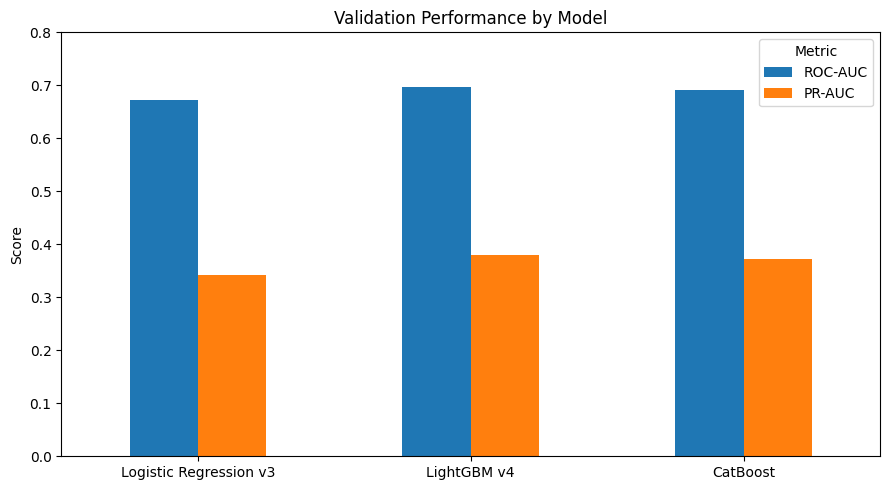

In [133]:
import matplotlib.pyplot as plt

plot_df = model_comparison_3.set_index("Model")

ax = plot_df.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Validation Performance by Model")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 0.8)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    FIGURES_DIR / "model_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [134]:
model_comparison_3.to_csv(
    RESULTS_DIR / "three_model_comparison.csv",
    index=False
)

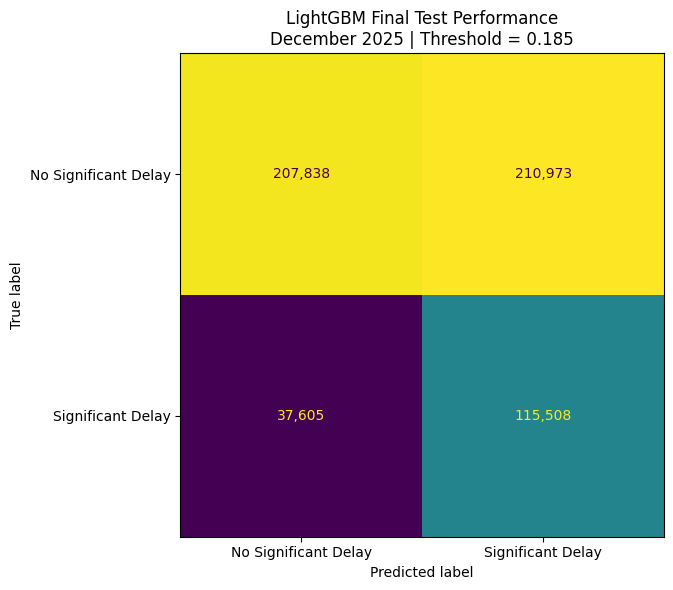

In [127]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test_v4,
    test_pred_v4,
    display_labels=["No Significant Delay", "Significant Delay"],
    values_format=",",
    ax=ax,
    colorbar=False
)

ax.set_title(
    "LightGBM Final Test Performance\n"
    "December 2025 | Threshold = 0.185"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "lightgbm_test_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [128]:
importance_v4 = pd.DataFrame({
    "feature": model_v4_full.booster_.feature_name(),
    "importance_gain": model_v4_full.booster_.feature_importance(
        importance_type="gain"
    )
})

importance_v4["importance_pct"] = (
    100 * importance_v4["importance_gain"]
    / importance_v4["importance_gain"].sum()
)

importance_v4 = importance_v4.sort_values(
    "importance_pct",
    ascending=False
)

importance_v4.head(15)

,feature,importance_gain,importance_pct
5,scheduled_dep_hour,1.352834e+06,19.387373
6,scheduled_arr_hour,7.741005e+05,11.093578
25,route_delay_rate_7d_final,7.719785e+05,11.063168
1,Origin,5.000799e+05,7.166609
3,Month,4.463522e+05,6.396641
2,Dest,3.288000e+05,4.712009
4,DayOfWeek,3.218695e+05,4.612688
36,wx_visibility_km,2.957880e+05,4.238917
0,Reporting_Airline,2.449220e+05,3.509960
34,wx_temperature_c,2.440804e+05,3.497898


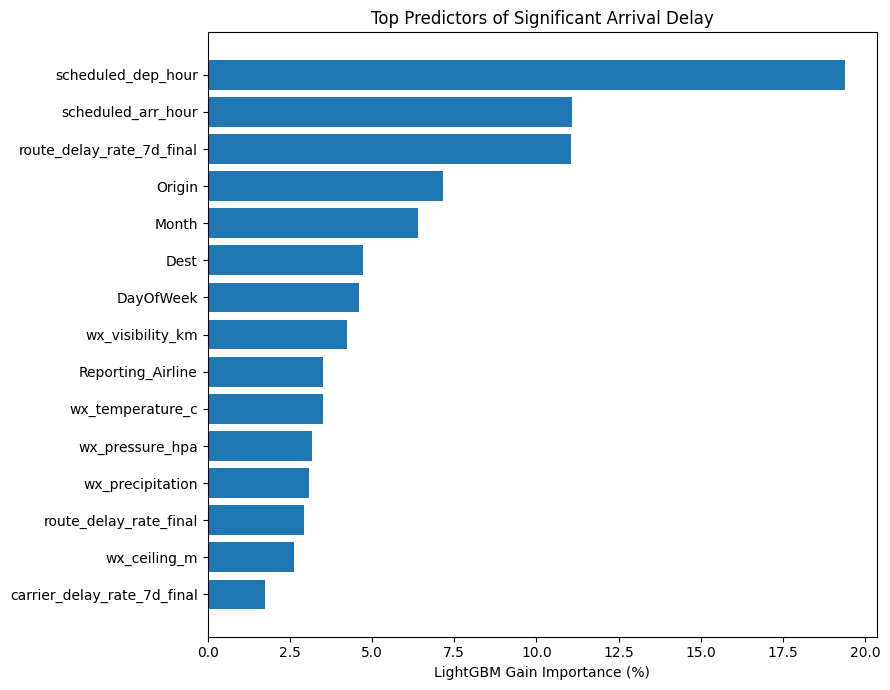

In [129]:
top_features_v4 = importance_v4.head(15).sort_values(
    "importance_pct",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    top_features_v4["feature"],
    top_features_v4["importance_pct"]
)

ax.set_title("Top Predictors of Significant Arrival Delay")
ax.set_xlabel("LightGBM Gain Importance (%)")
ax.set_ylabel("")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "lightgbm_feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [130]:
importance_v4.to_csv(
    RESULTS_DIR / "lightgbm_feature_importance.csv",
    index=False
)

## Final Modeling Summary

The flight disruption modeling phase is complete.

### Modeling progression

1. **Logistic Regression v1**
   - Established the initial predeparture baseline.

2. **Logistic Regression v2**
   - Added leakage-safe cumulative and 7-day historical performance features for carriers, origins, destinations, and routes.

3. **Logistic Regression v3**
   - Added point-in-time NOAA weather conditions.
   - Controlled weather ablation showed modest but consistent improvement over the matched no-weather model.

4. **LightGBM v4 — Final Model**
   - Added nonlinear relationships and interactions while retaining the same 46 predeparture features.
   - Outperformed logistic regression on validation ROC-AUC and PR-AUC.
   - Selected as the final production-style model.

5. **CatBoost benchmark**
   - Evaluated as an additional nonlinear alternative on the same 1-million-row development sample.
   - Performed slightly below LightGBM and required substantially more training time.
   - No full-data CatBoost fit was pursued.

### Final LightGBM validation performance

- ROC-AUC: **0.6966**
- PR-AUC: **0.3806**
- Validation-selected threshold: **0.185**
- Precision at selected threshold: **32.12%**
- Recall at selected threshold: **62.57%**
- F1: **42.45%**

### Final untouched December 2025 test

- Flights: **571,924**
- Delay prevalence: **26.77%**
- ROC-AUC: **0.6870**
- PR-AUC: **~0.4597**
- Precision: **35.38%**
- Recall: **75.44%**
- F1: **48.17%**
- Accuracy: **56.54%**

The locked validation threshold identified approximately three out of four significantly delayed flights in the out-of-time test period. The model generates a substantial number of false positives and should therefore be interpreted as a **predeparture disruption-risk screening and prioritization system**, not a deterministic delay classifier.

### Key predictive signals

LightGBM gain importance identified:

- scheduled departure hour,
- scheduled arrival hour,
- recent 7-day route delay rate,
- origin airport,
- month,
- destination airport,
- day of week,
- visibility,
- airline,
- temperature,
- pressure,
- precipitation,
- ceiling height

as important predictive inputs.

Weather contributed incremental predictive information, but operational timing, airport context, and recent network performance remained dominant.

### Final artifact

`models/lightgbm_v4.joblib`

No additional model tuning was performed using the December holdout period.